In [285]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from windrose import WindroseAxes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

### Read Data

In [233]:
# Read data and structure data with datatime index and correct headers
data = pd.read_excel('EO7 Work Sample Stimulus Data.xlsx', skiprows=2)
data.drop(['Date', 'Time'], axis=1, inplace=True)
data.index = pd.date_range(start='2019-11-01 01:00:00', end='2019-12-16 00:00:00', freq='H')
data

,BRINGELLY HUMID 1h average [%],BRINGELLY NEPH 1h average [bsp],BRINGELLY OZONE 1h average [pphm],BRINGELLY PM10 1h average [µg/m³],BRINGELLY PM2.5 1h average [µg/m³],BRINGELLY SOLAR 1h average [W/m²],BRINGELLY TEMP 1h average [°C],BRINGELLY WDR 1h average [°],BRINGELLY WSP 1h average [m/s],WYONG HUMID 1h average [%],...,WYONG WSP 1h average [m/s],WOLLONGONG HUMID 1h average [%],WOLLONGONG NEPH 1h average [bsp],WOLLONGONG OZONE 1h average [pphm],WOLLONGONG PM10 1h average [µg/m³],WOLLONGONG PM2.5 1h average [µg/m³],WOLLONGONG SOLAR 1h average [W/m²],WOLLONGONG TEMP 1h average [°C],WOLLONGONG WDR 1h average [°],WOLLONGONG WSP 1h average [m/s]
2019-11-01 01:00:00,97.724,0.972,0.287,15.703,17.807,2.744,12.493,208.897,0.722,100.227,...,0.268,84.902,1.076,1.349,27.459,22.608,NaN,16.012,20.584,0.557
2019-11-01 02:00:00,98.014,0.887,NaN,7.568,14.885,2.783,11.550,202.980,0.523,100.739,...,0.659,86.325,1.276,NaN,32.362,29.361,NaN,15.019,53.212,0.368
2019-11-01 03:00:00,98.171,1.035,0.101,9.846,12.914,2.785,10.791,228.684,0.240,100.907,...,0.540,87.723,1.388,0.824,32.262,27.435,NaN,14.265,249.519,0.150
2019-11-01 04:00:00,98.265,0.753,0.012,11.829,14.716,2.806,10.241,209.827,0.248,101.007,...,0.802,89.185,1.344,0.272,30.619,35.436,NaN,13.532,259.919,0.254
2019-11-01 05:00:00,98.351,0.737,0.005,3.877,17.766,4.047,9.813,213.261,0.462,101.036,...,1.126,90.491,1.320,0.021,36.836,33.108,NaN,13.031,247.000,0.303
2019-11-01 06:00:00,98.474,0.910,0.105,31.974,18.112,57.787,11.659,209.838,0.344,101.049,...,0.798,90.448,1.307,0.060,51.083,30.545,NaN,13.480,243.061,0.122
2019-11-01 07:00:00,97.540,1.158,0.343,61.412,26.229,125.266,14.934,196.587,0.629,101.067,...,0.427,78.554,1.588,0.728,47.143,20.250,NaN,17.441,7.768,1.105
2019-11-01 08:00:00,85.654,1.243,0.888,97.280,25.729,236.179,17.557,177.765,0.627,89.301,...,0.643,72.831,1.673,1.388,55.025,24.967,NaN,19.473,42.621,1.134
2019-11-01 09:00:00,76.037,1.724,1.978,61.685,25.727,434.570,19.338,218.661,0.167,74.274,...,1.267,72.966,1.261,2.439,50.897,35.357,NaN,20.223,67.937,2.219
2019-11-01 10:00:00,63.383,2.356,2.918,68.908,31.379,804.428,22.346,83.029,0.659,65.436,...,1.158,72.921,2.377,3.660,70.745,33.062,NaN,20.688,55.846,2.775


In [83]:
# Check missing data
missing_data = data.isnull().sum()
missing_data_percentage = (missing_data / len(data)) * 100
missing_data_info = pd.DataFrame({'Missing Data': missing_data, 'Percentage (%)': missing_data_percentage})
missing_data_info.sort_values(by='Percentage (%)', ascending=False)

,Missing Data,Percentage (%)
WOLLONGONG SOLAR 1h average [W/m²],1080,100.000000
WYONG OZONE 1h average [pphm],121,11.203704
BRINGELLY PM2.5 1h average [µg/m³],60,5.555556
WOLLONGONG OZONE 1h average [pphm],60,5.555556
BRINGELLY OZONE 1h average [pphm],53,4.907407
WYONG PM2.5 1h average [µg/m³],50,4.629630
WOLLONGONG PM2.5 1h average [µg/m³],46,4.259259
BRINGELLY PM10 1h average [µg/m³],36,3.333333
WYONG PM10 1h average [µg/m³],34,3.148148
WOLLONGONG PM10 1h average [µg/m³],30,2.777778


In [84]:
# Check the main characteristics of the data
data_description = data.describe().transpose()
data_description

,count,mean,std,min,25%,50%,75%,max
BRINGELLY HUMID 1h average [%],1077.0,58.776725,26.346562,8.015,36.31500,60.0500,81.48800,98.474
BRINGELLY NEPH 1h average [bsp],1073.0,1.334690,2.657000,0.028,0.19600,0.4910,1.13400,30.938
BRINGELLY OZONE 1h average [pphm],1027.0,2.802512,1.960903,-0.016,1.58000,2.5020,3.54150,14.388
BRINGELLY PM10 1h average [µg/m³],1044.0,52.167249,71.537662,-9.929,17.14425,30.3635,60.65750,632.991
BRINGELLY PM2.5 1h average [µg/m³],1020.0,27.899856,48.913041,-2.436,5.78975,11.9985,26.01200,404.853
BRINGELLY SOLAR 1h average [W/m²],1078.0,257.482647,326.276582,-2.918,3.06650,67.2300,499.20000,1096.819
BRINGELLY TEMP 1h average [°C],1077.0,20.269289,6.027195,5.375,16.16500,19.7600,24.17400,38.141
BRINGELLY WDR 1h average [°],1077.0,170.915431,88.589440,0.158,98.33900,183.5940,235.96700,359.464
BRINGELLY WSP 1h average [m/s],1077.0,1.805606,1.507683,0.029,0.54700,1.3950,2.66800,7.615
WYONG HUMID 1h average [%],1080.0,69.784557,21.364382,8.174,58.45550,73.5475,86.00050,101.411


In [234]:
# Set all the negative data to 0
data[data < 0] = 0

In [ ]:
# Drop columns with all null values and inputation
# data = data.dropna(axis=1, how='all')
data_interpolated = data.interpolate(method='linear', limit=3)
data_interpolated

### Pollution Data Variation

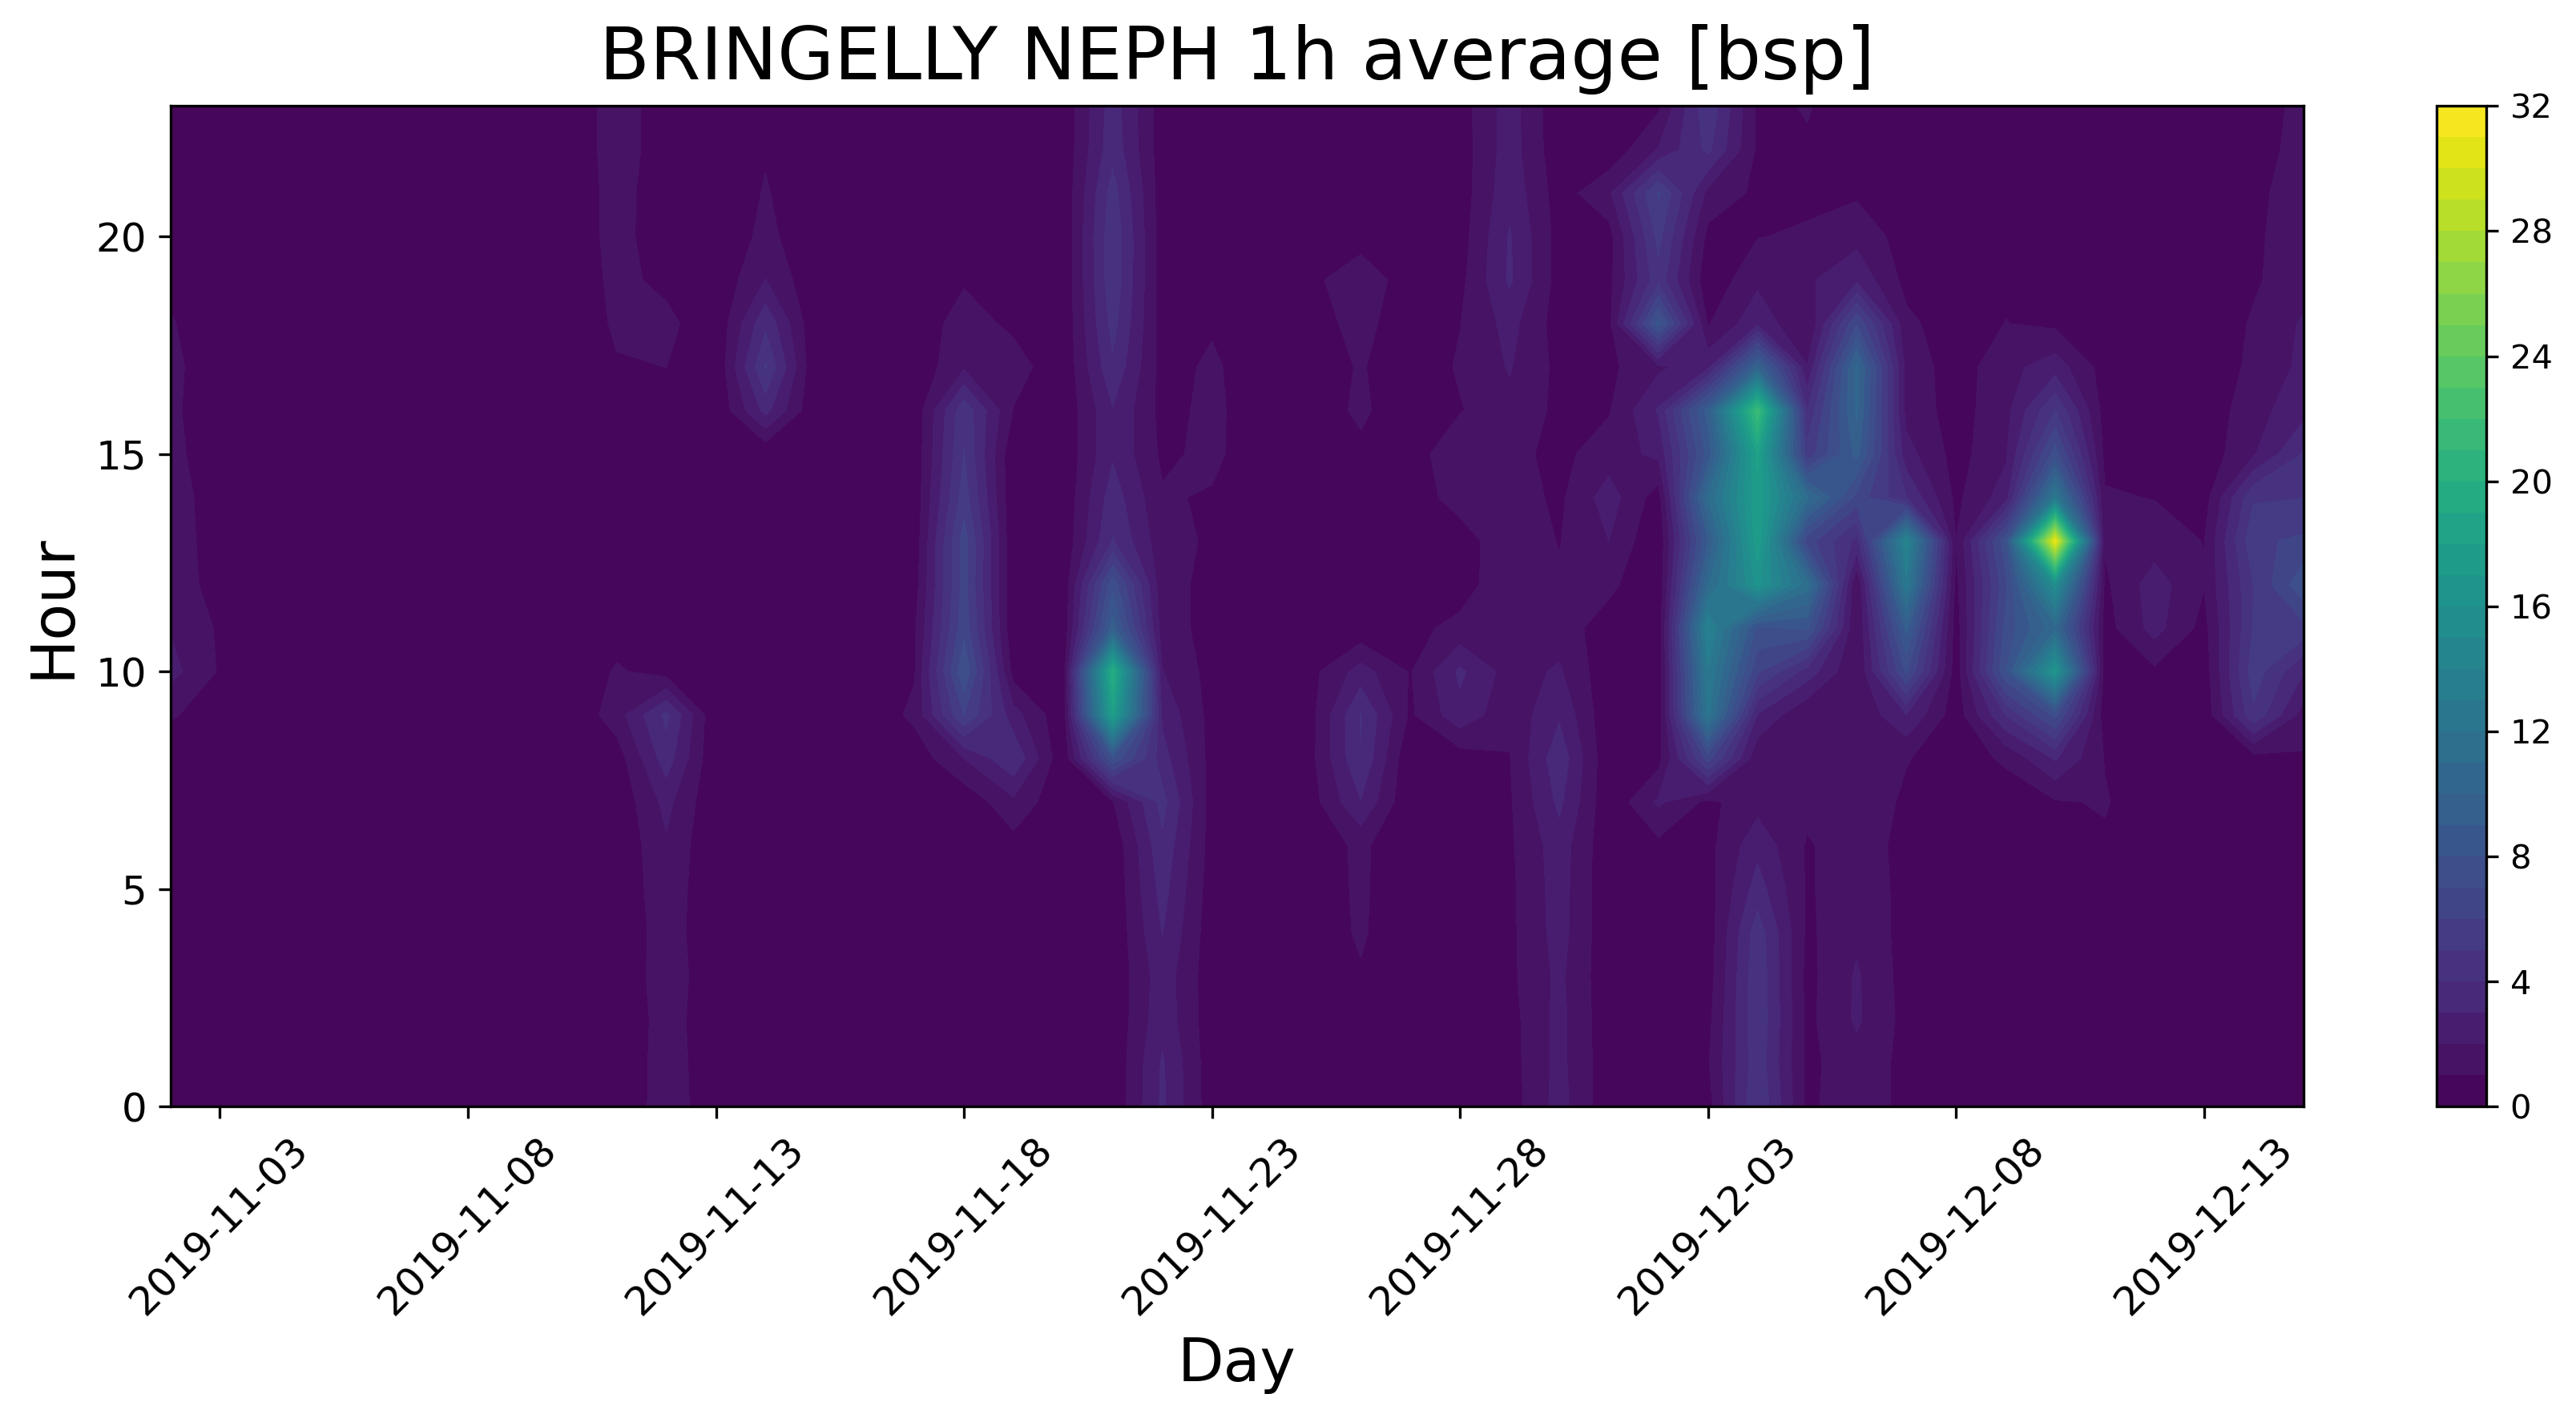

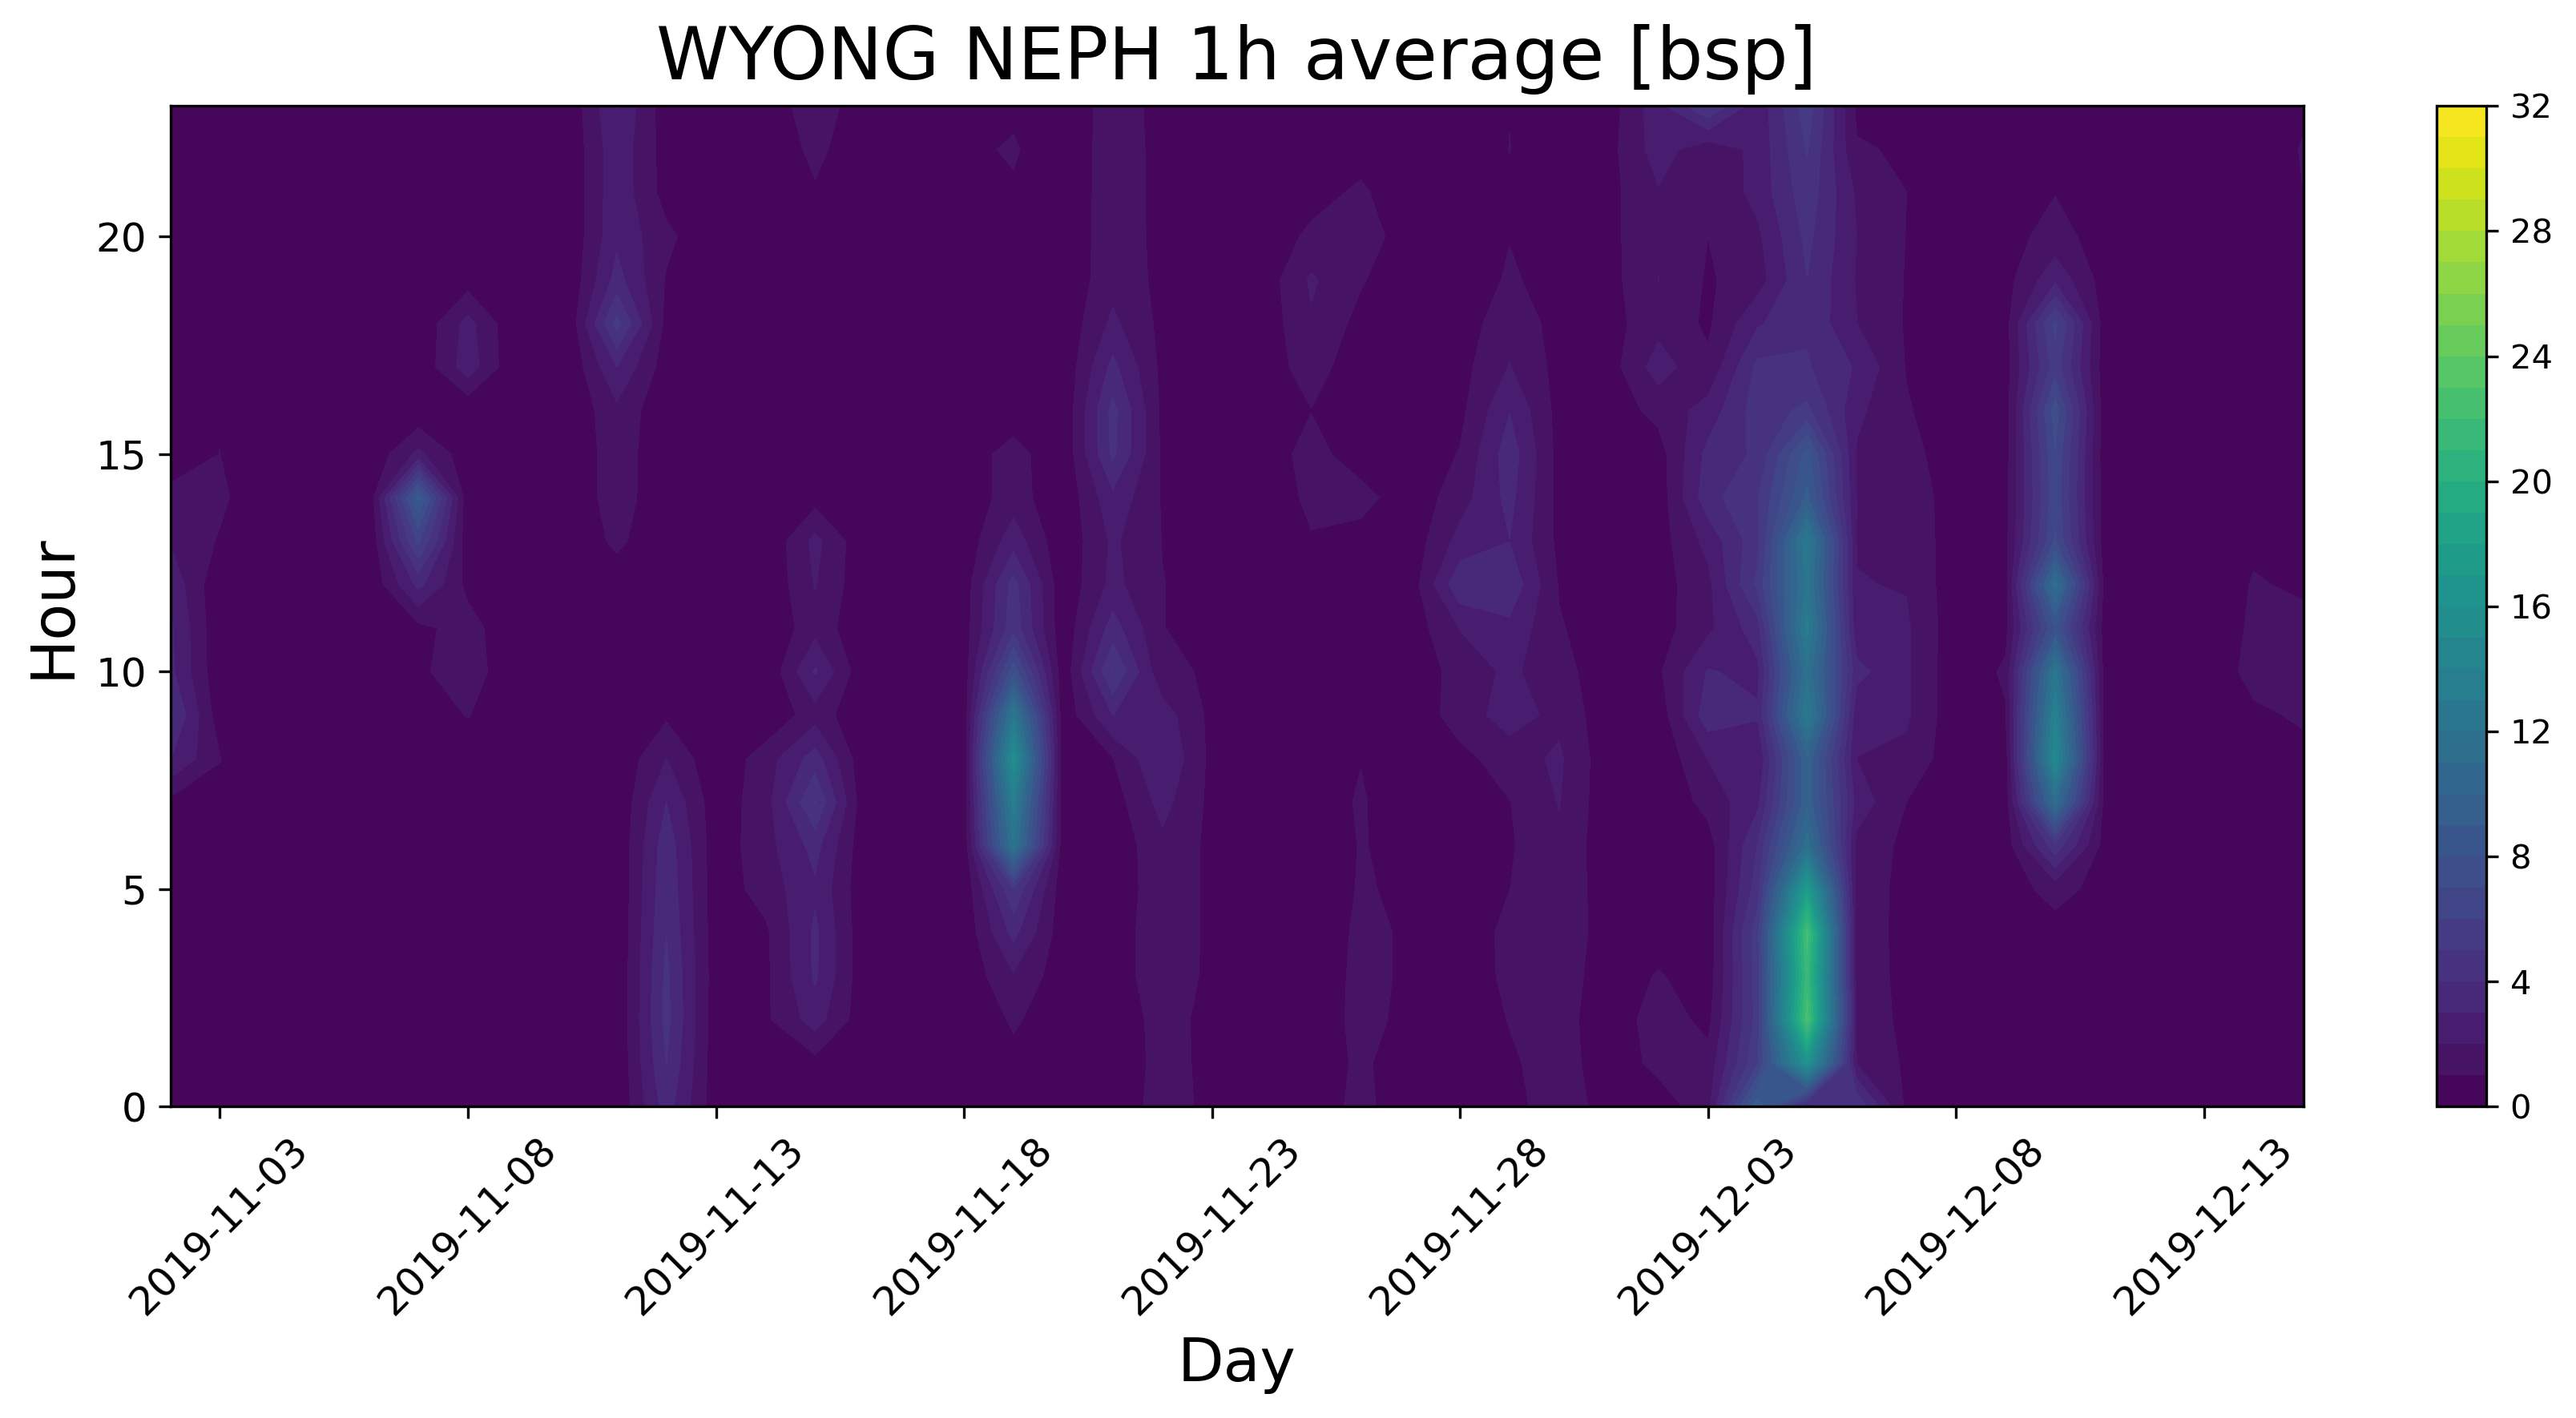

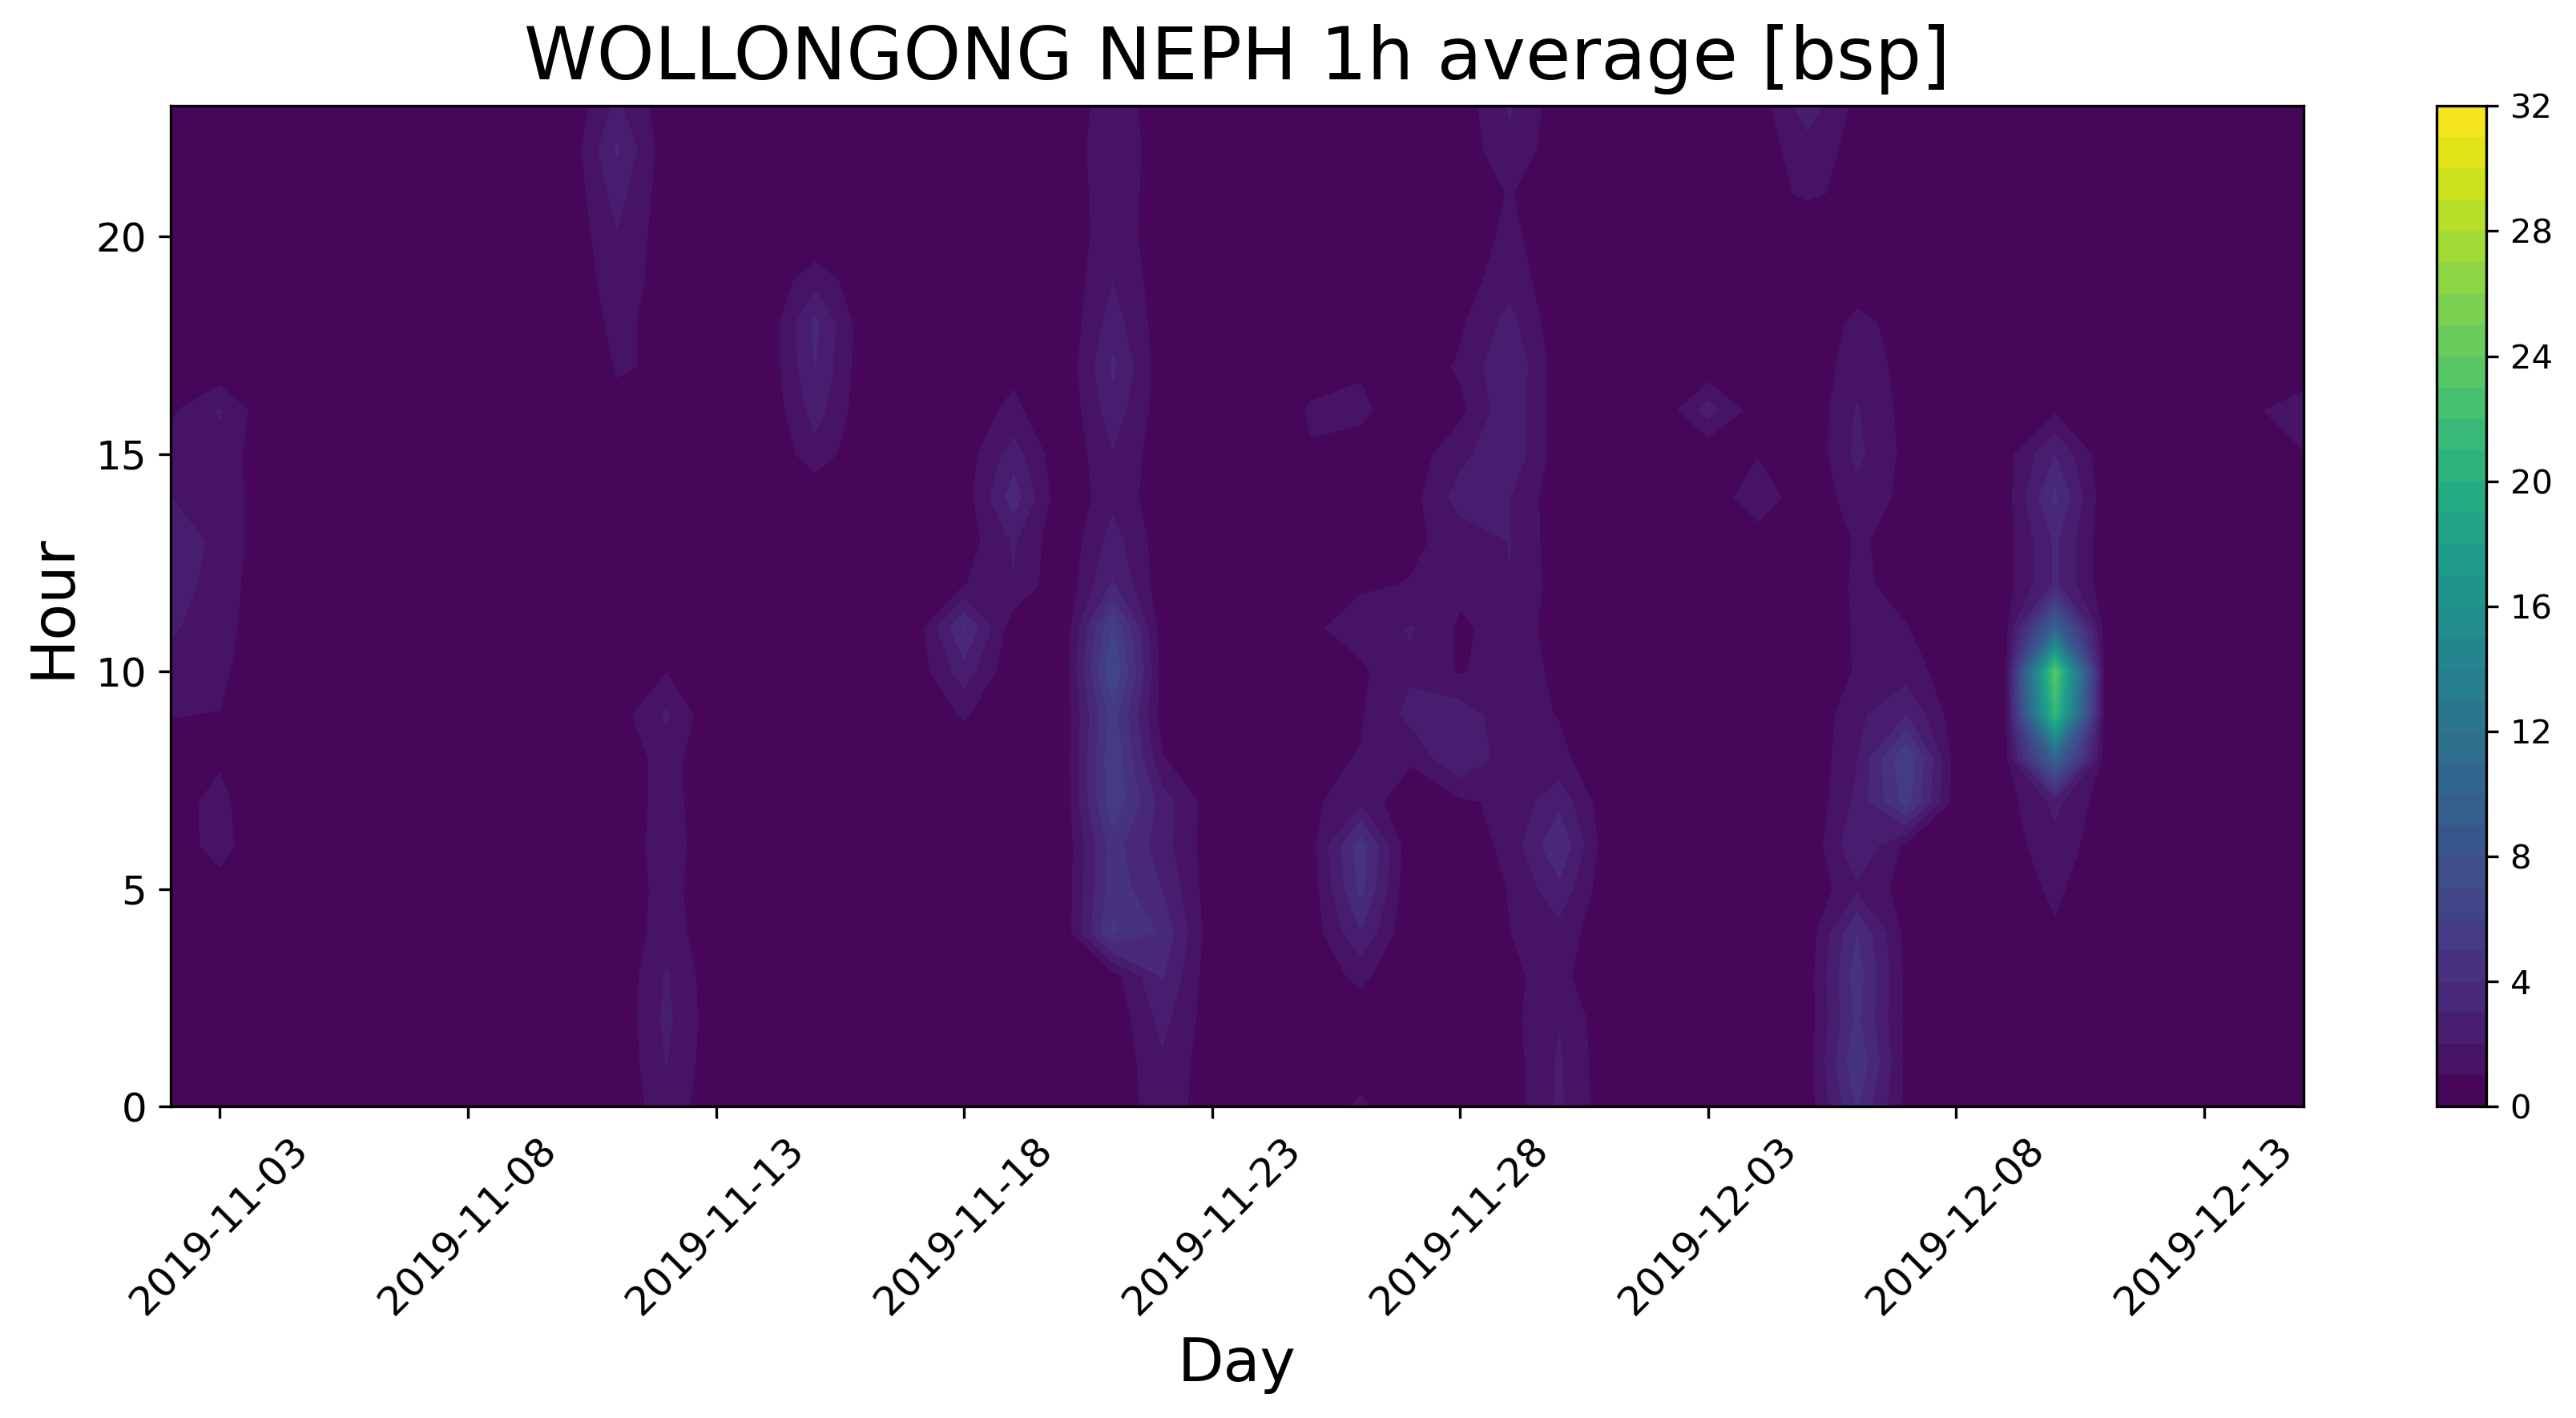

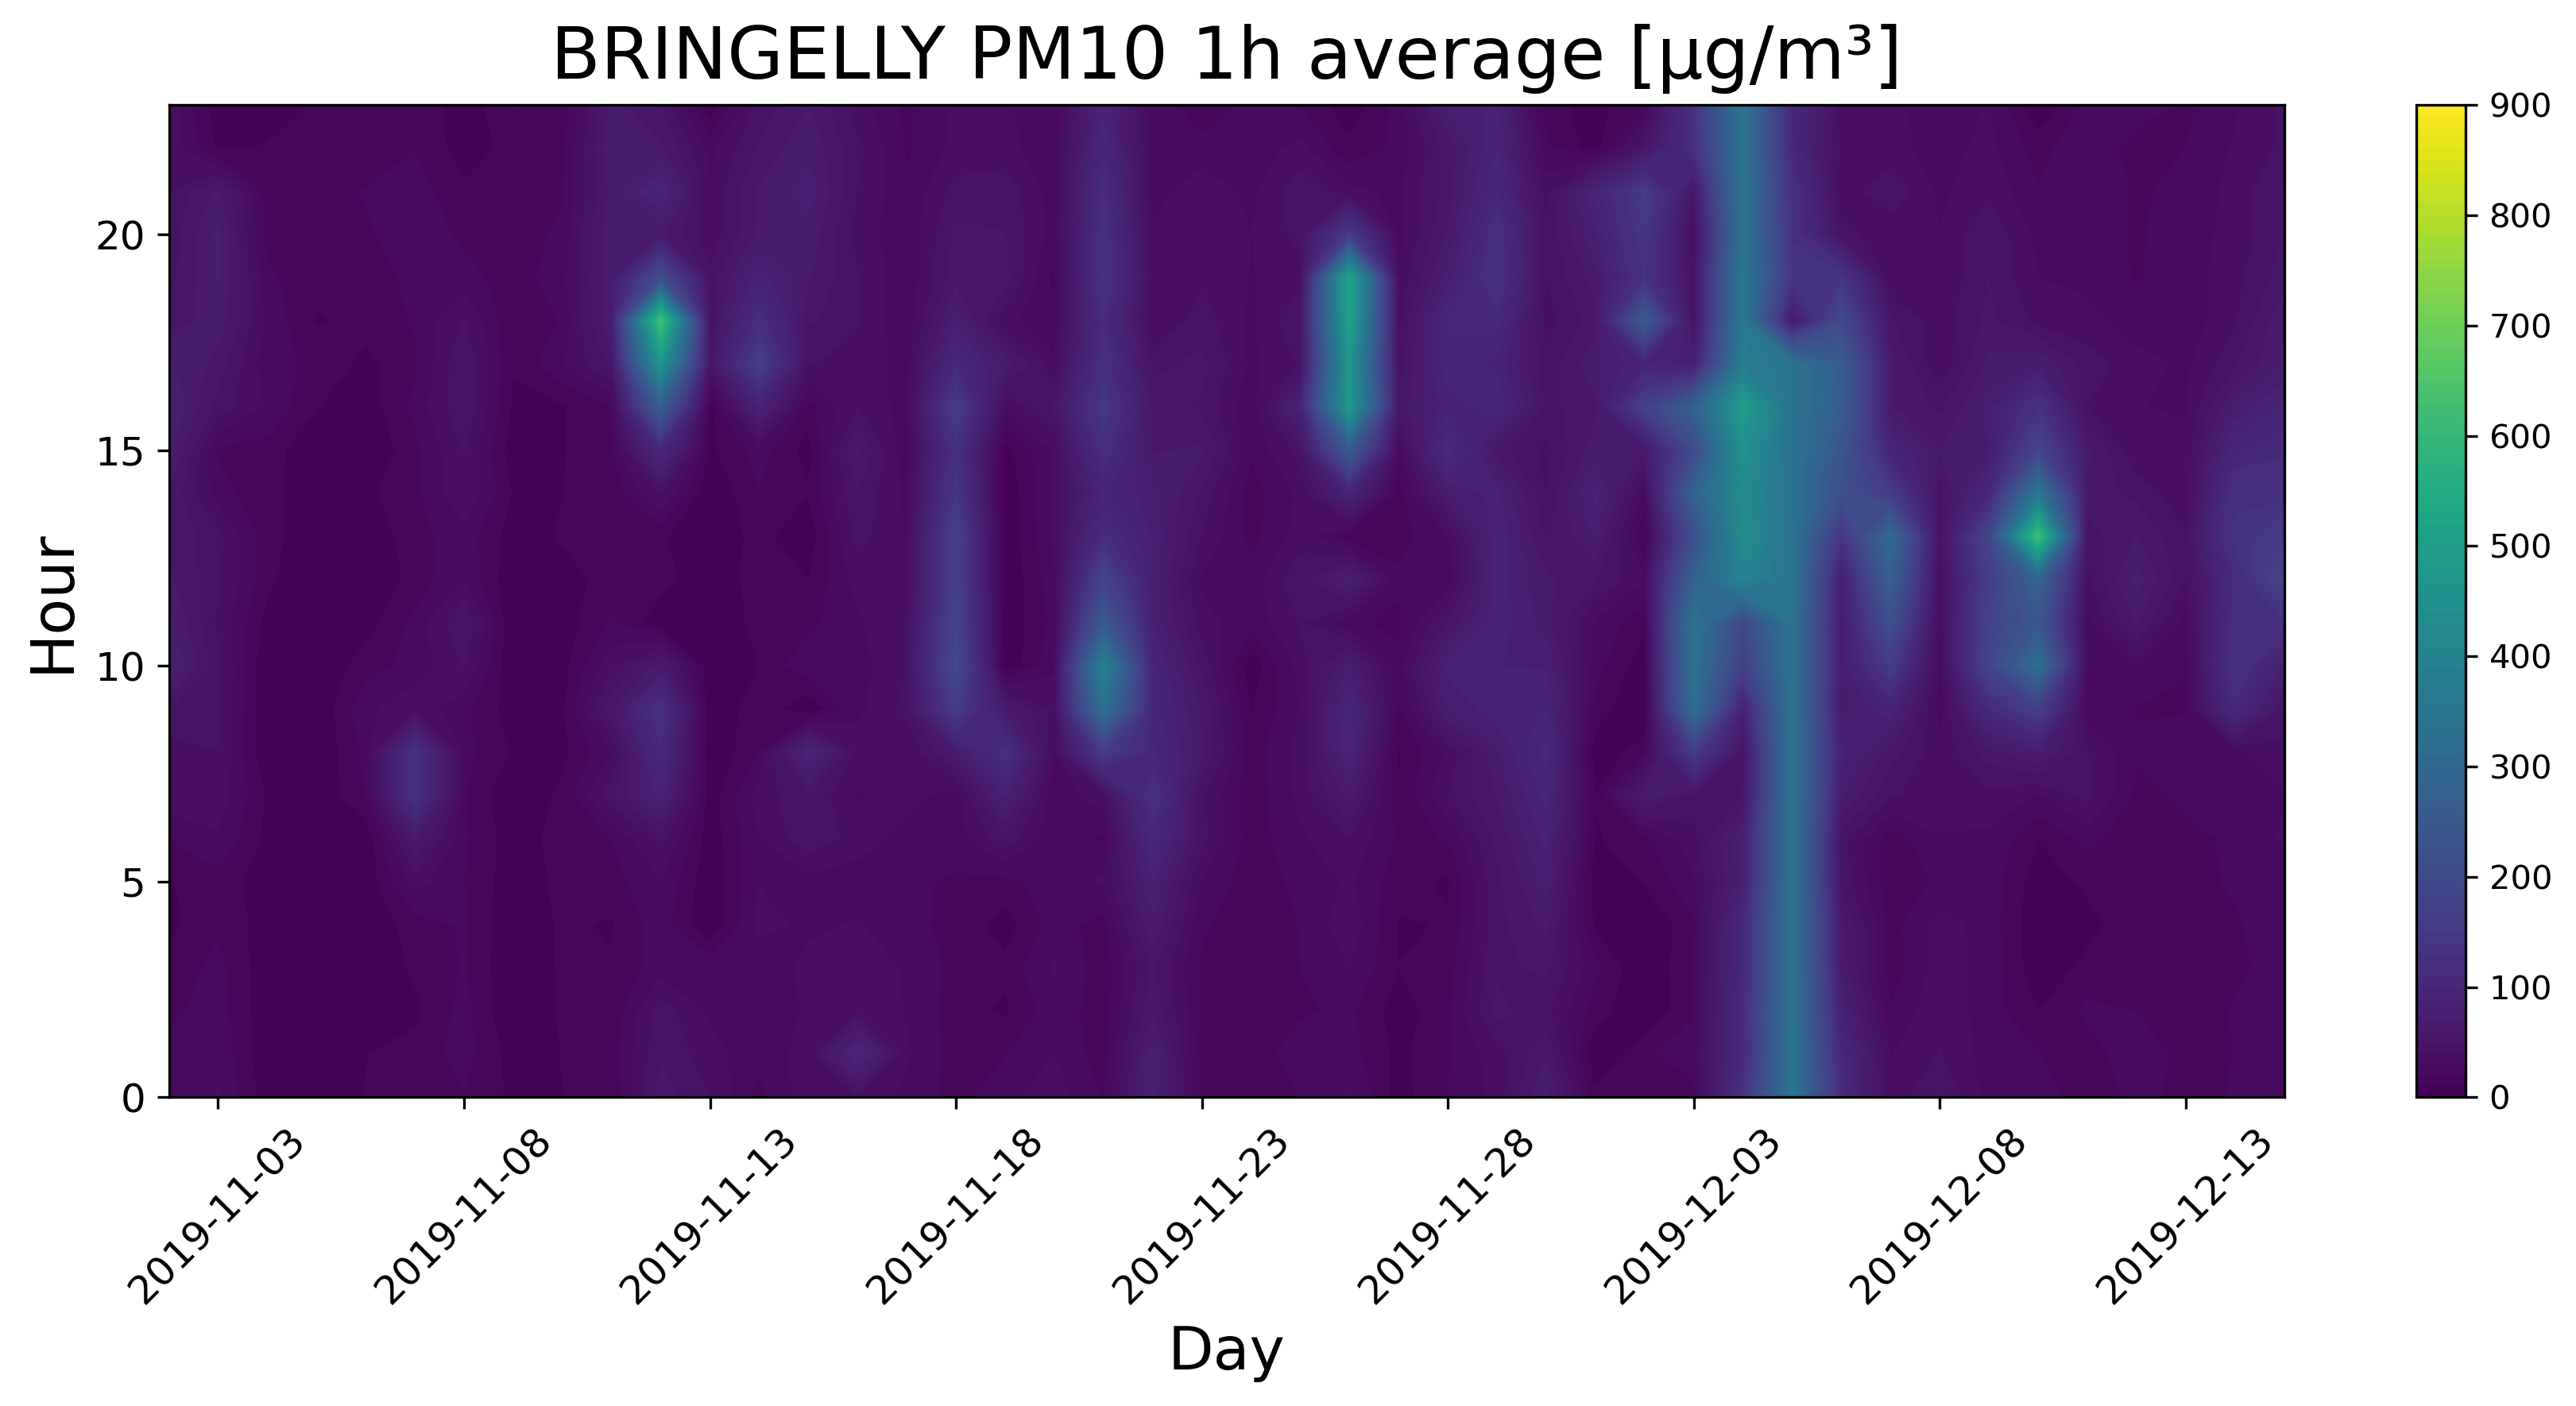

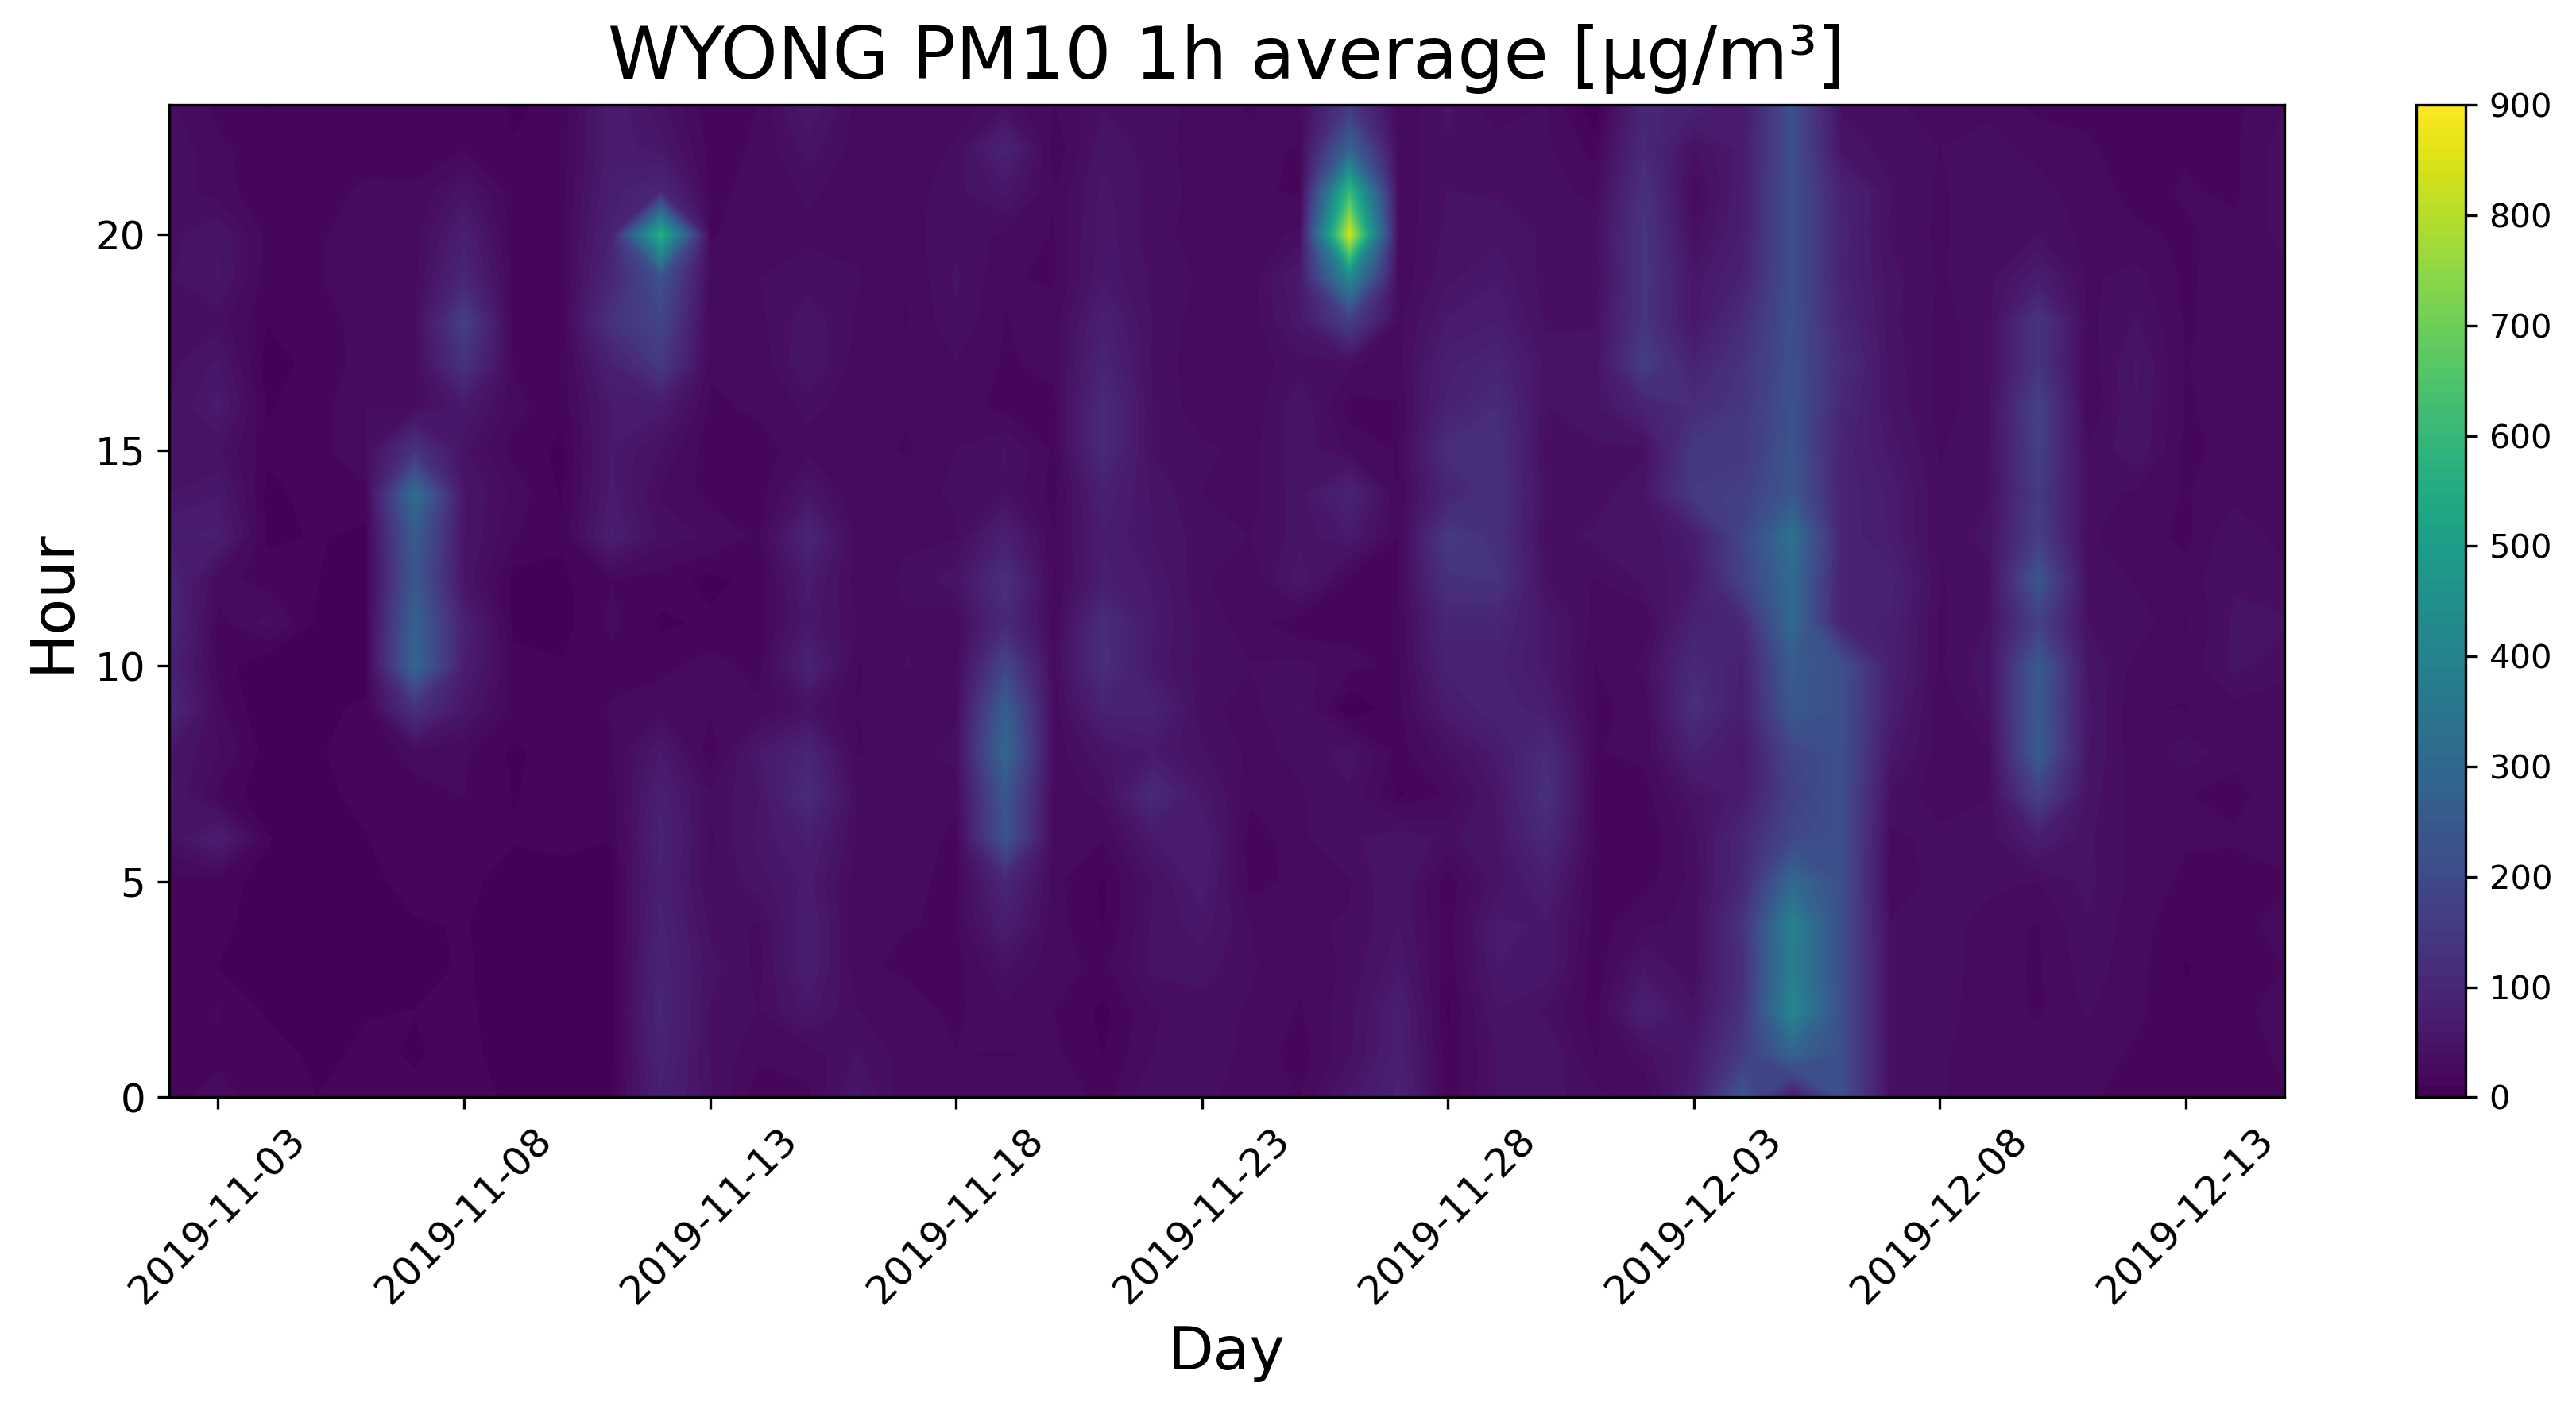

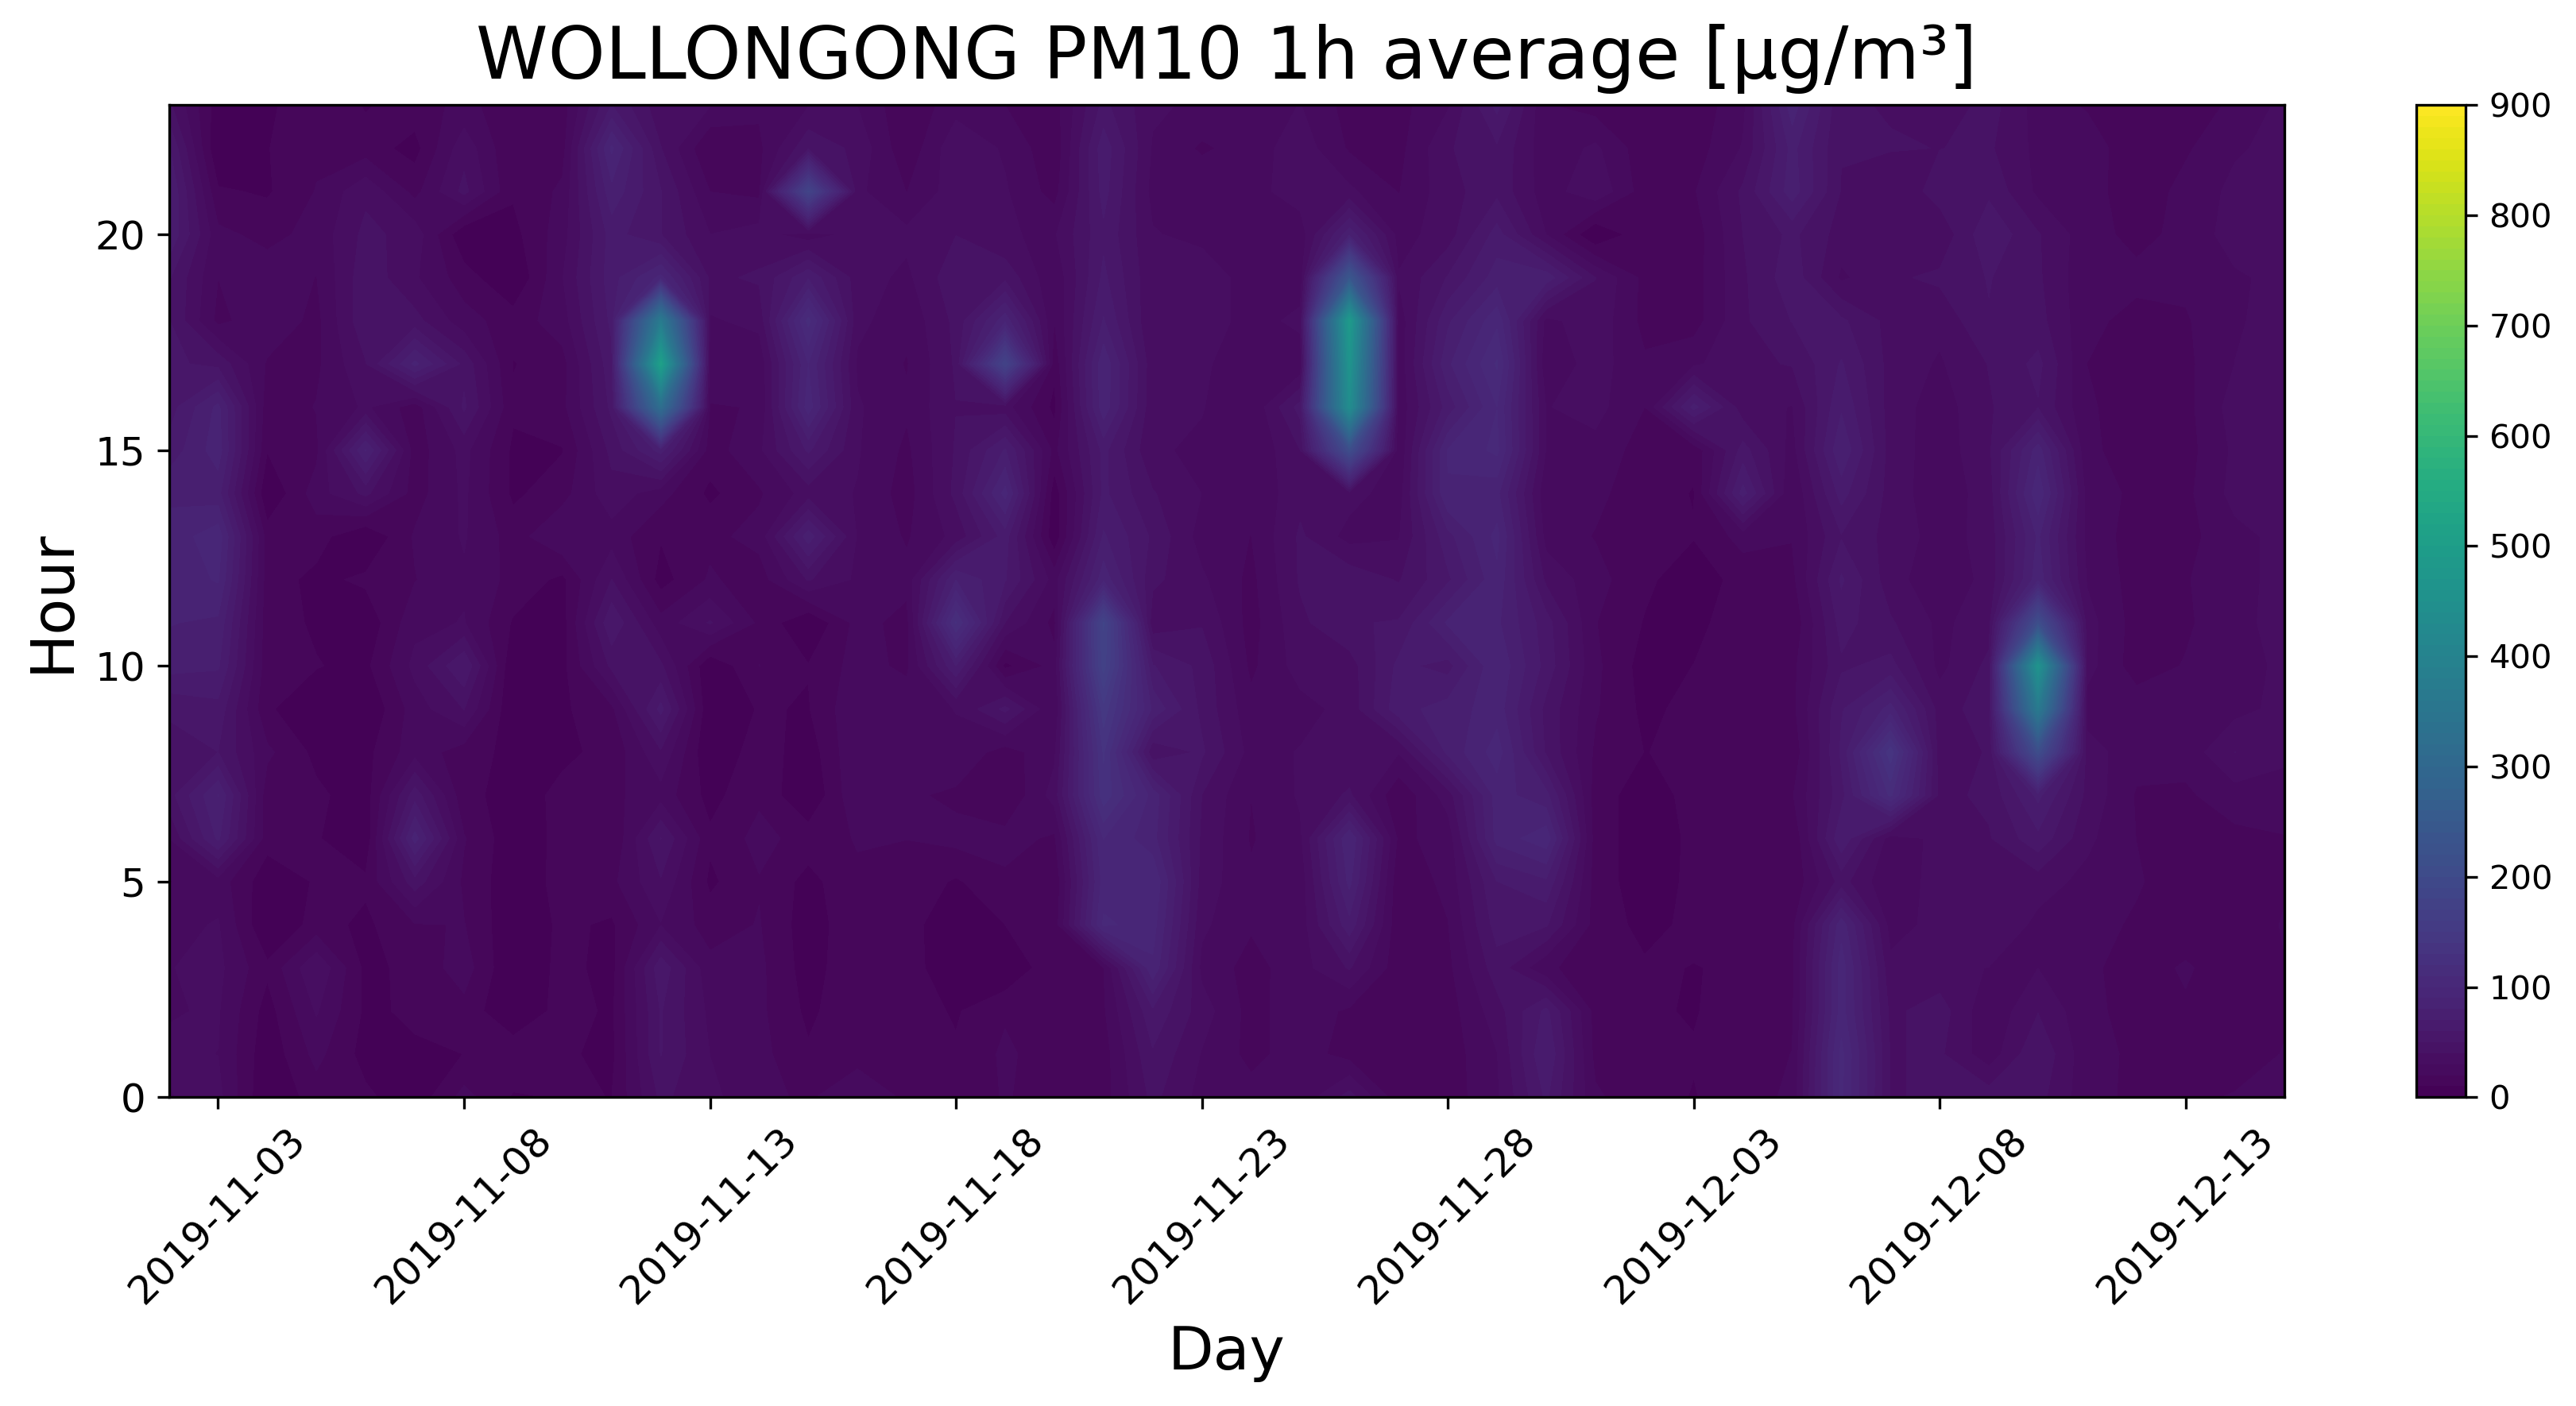

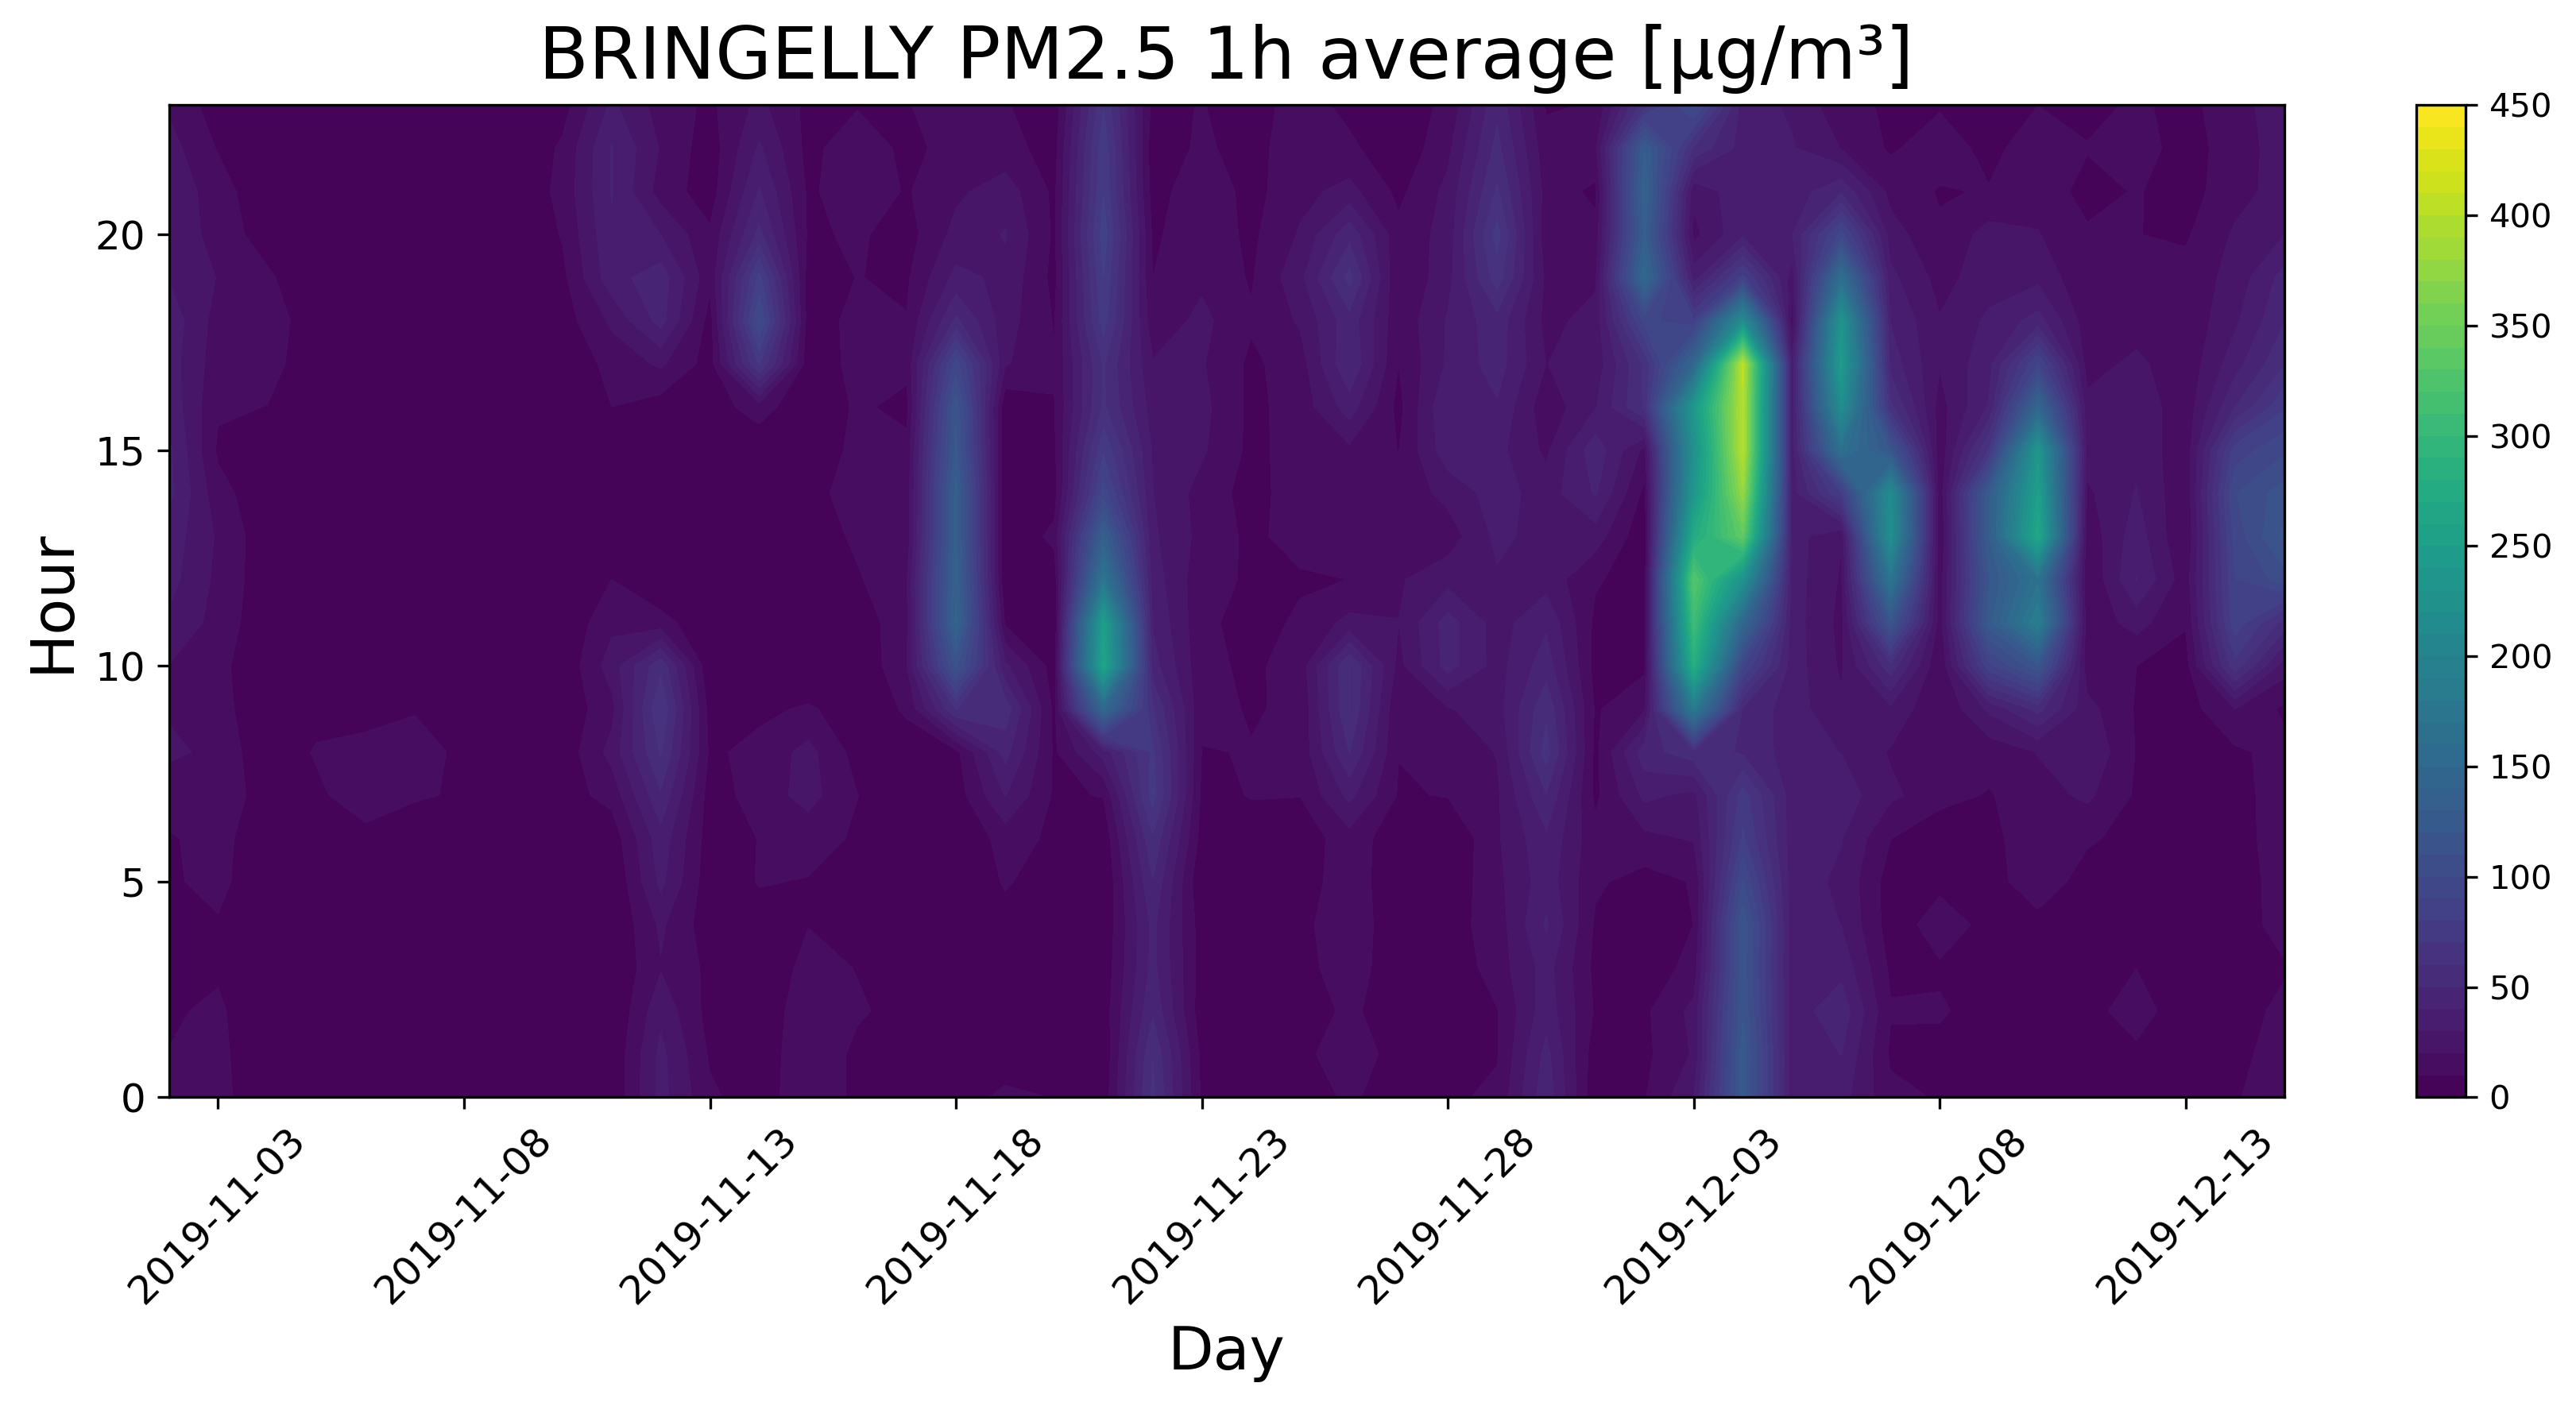

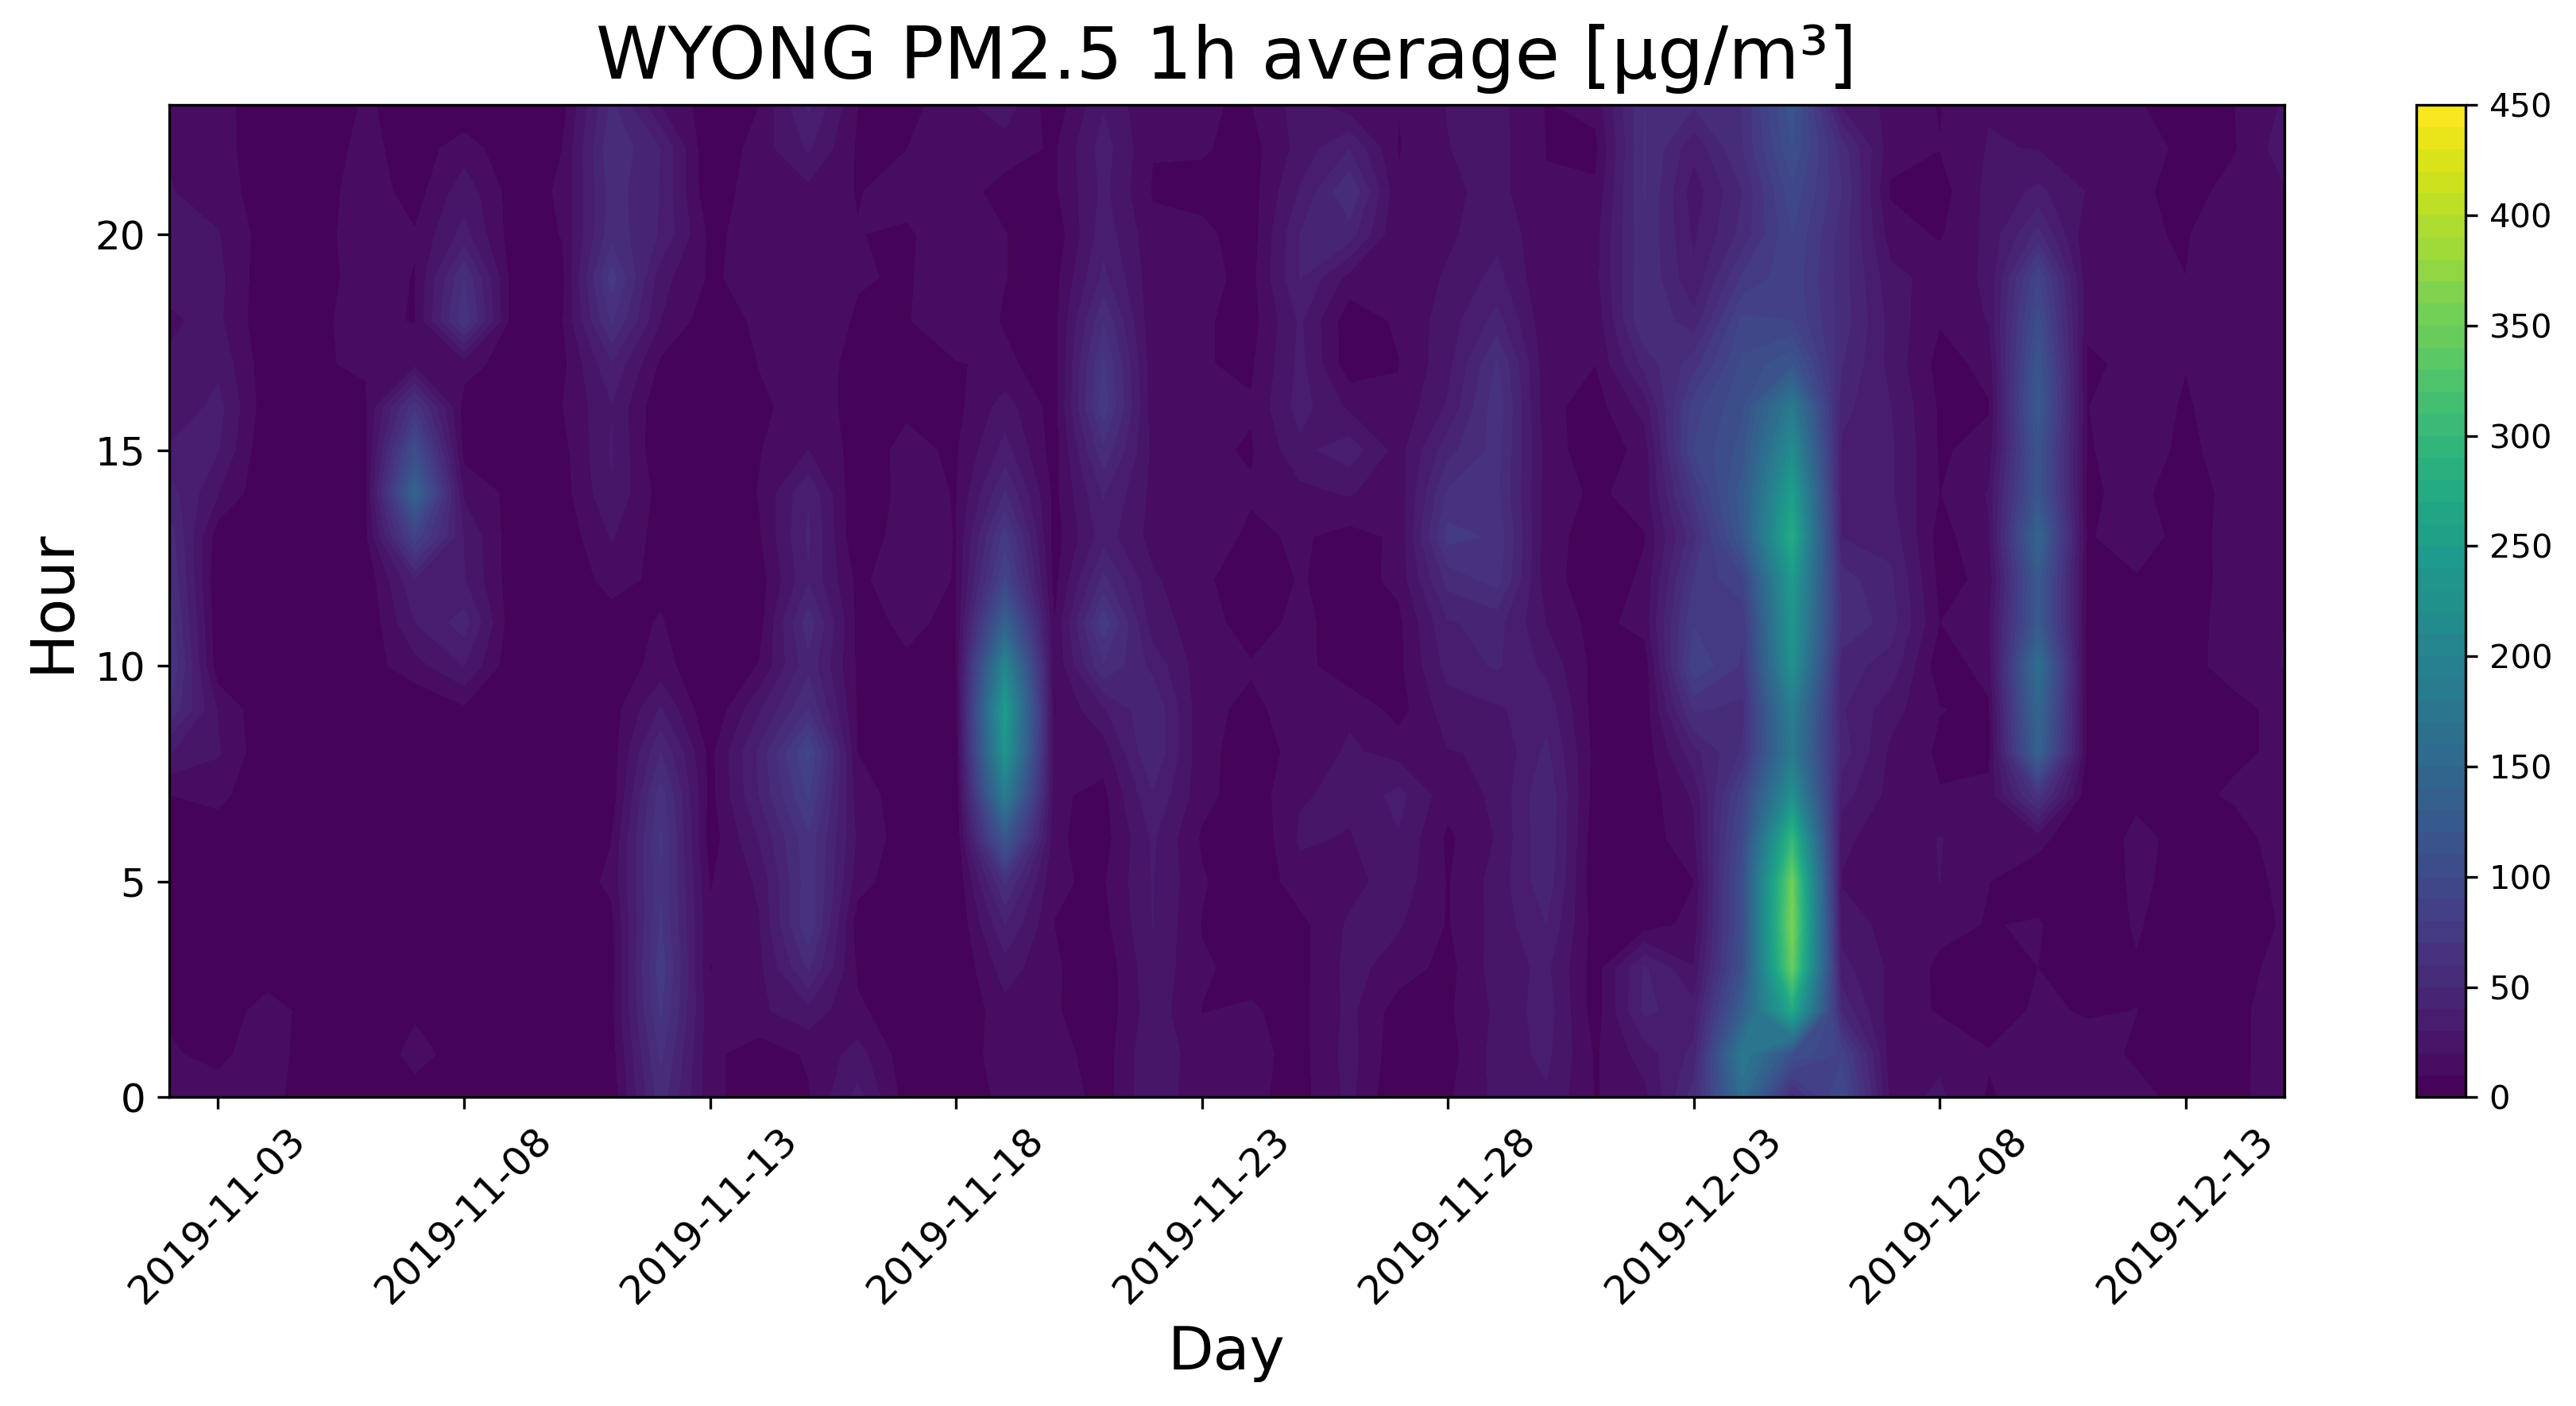

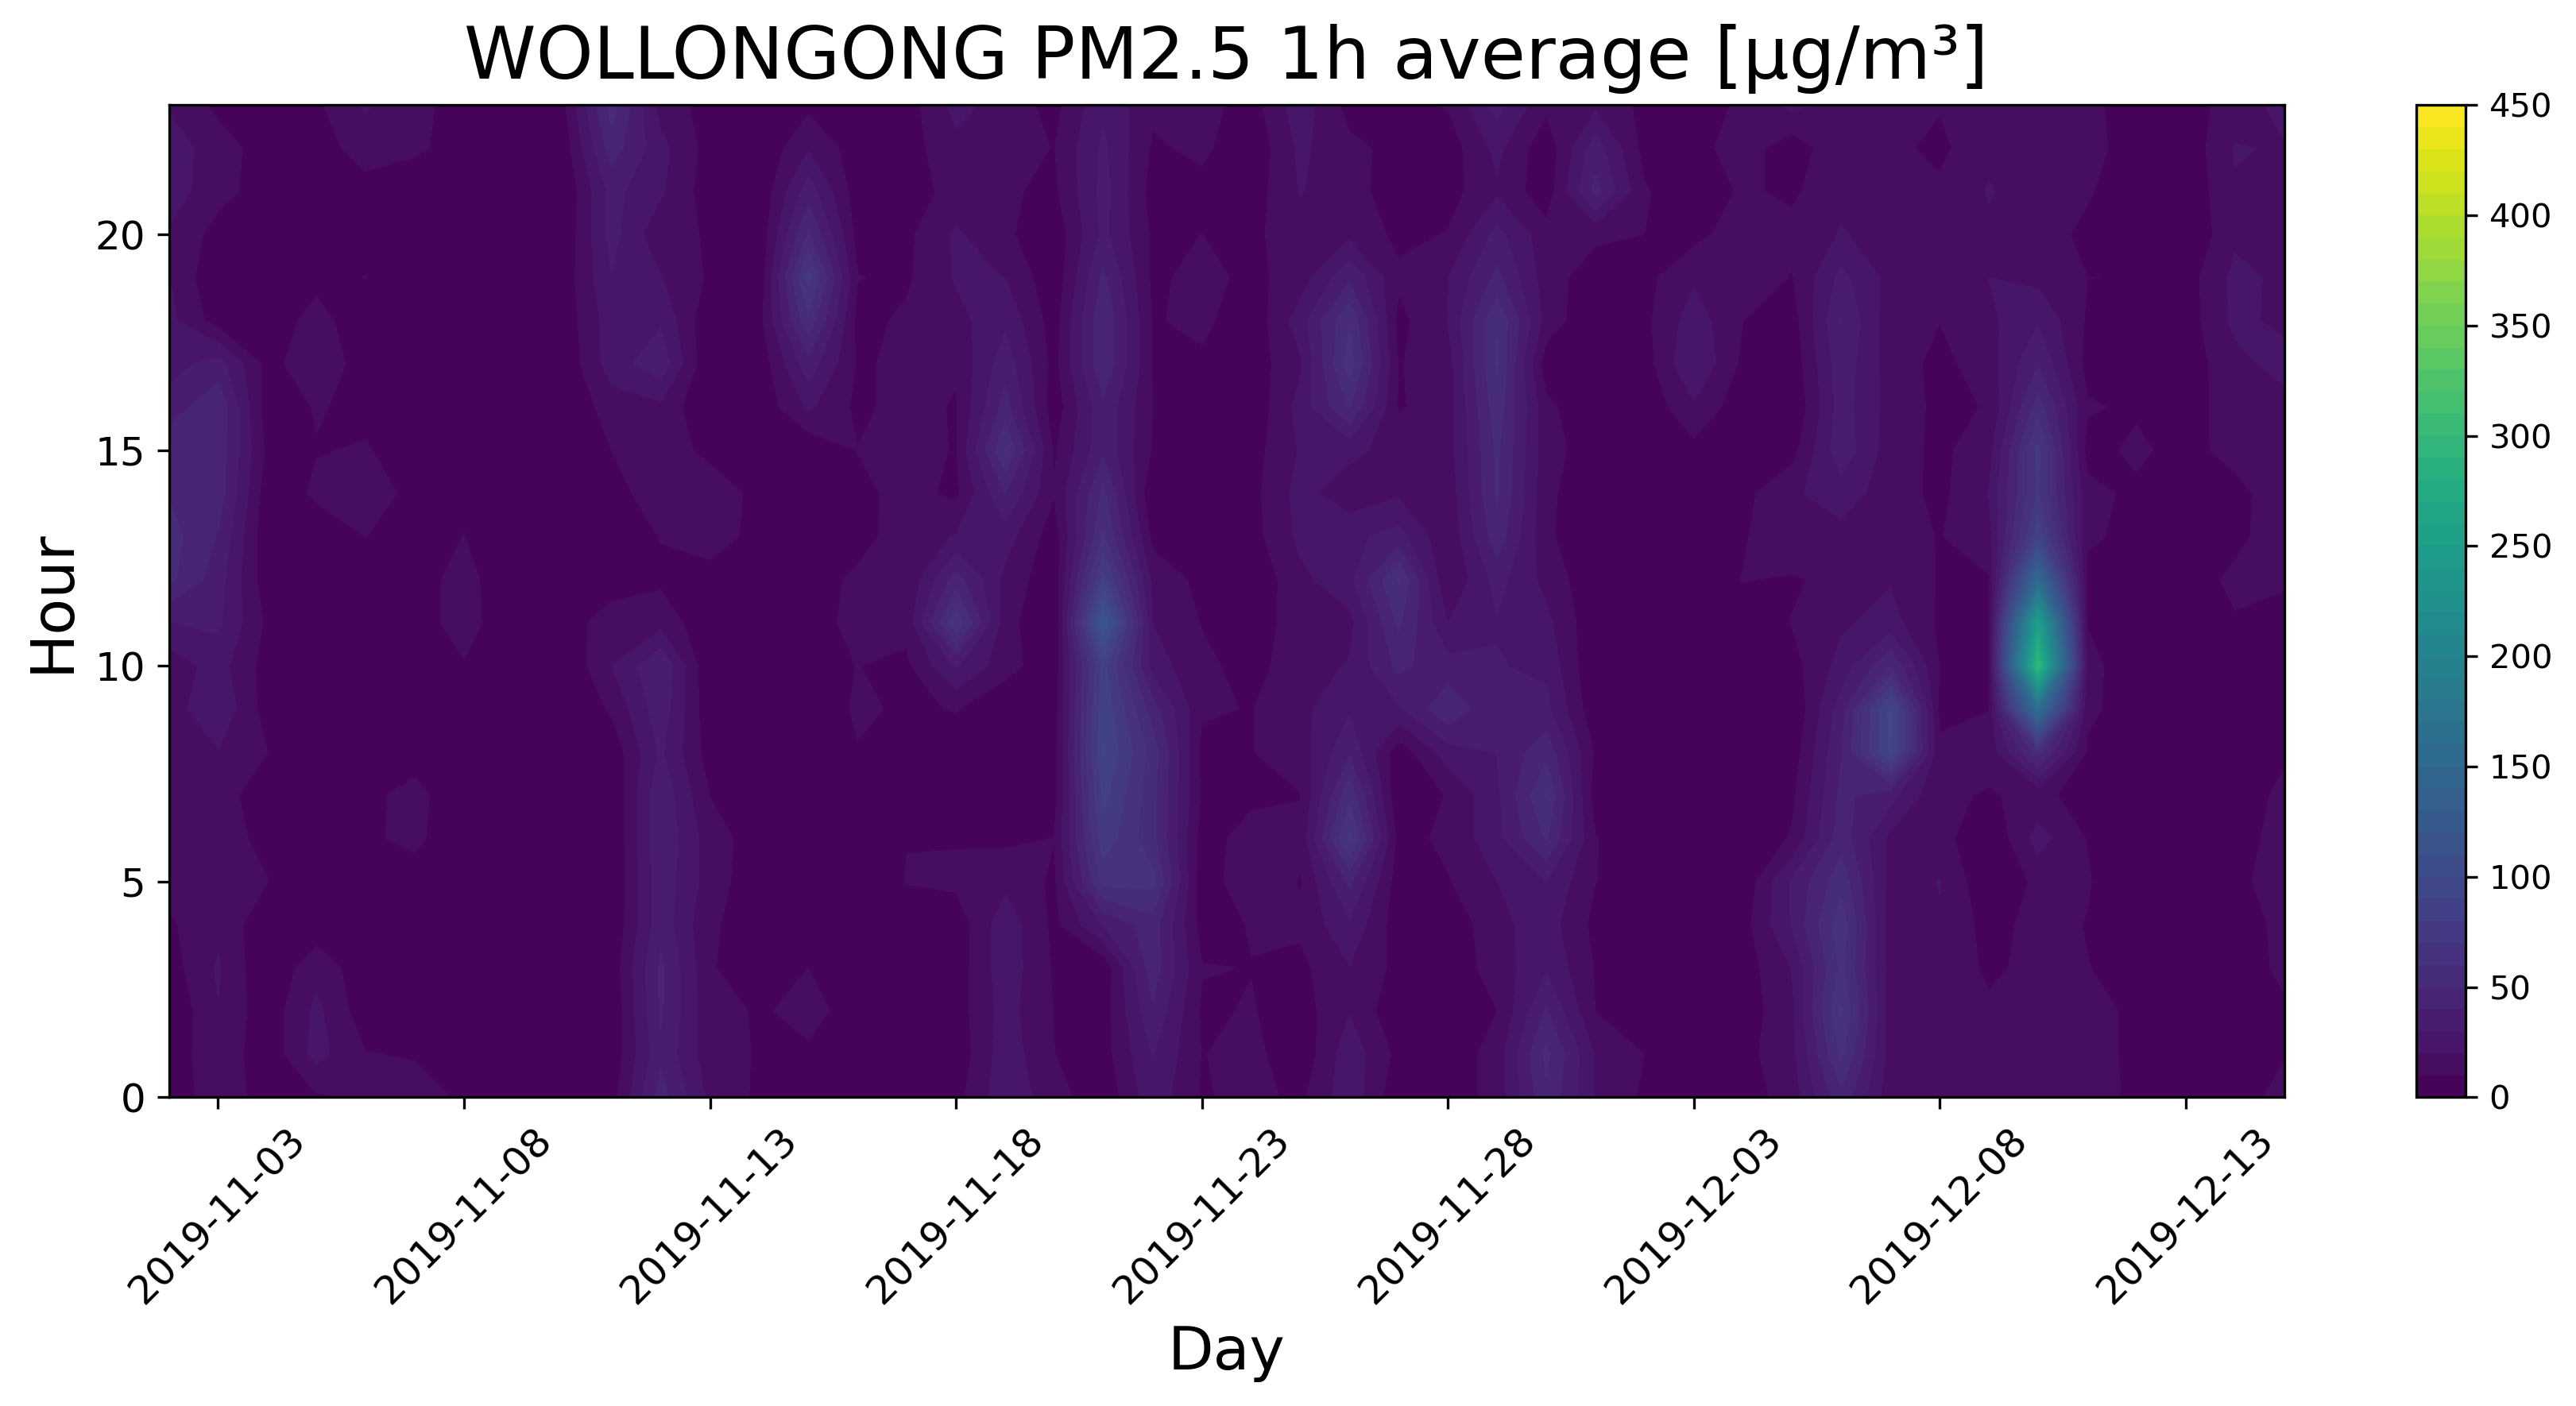

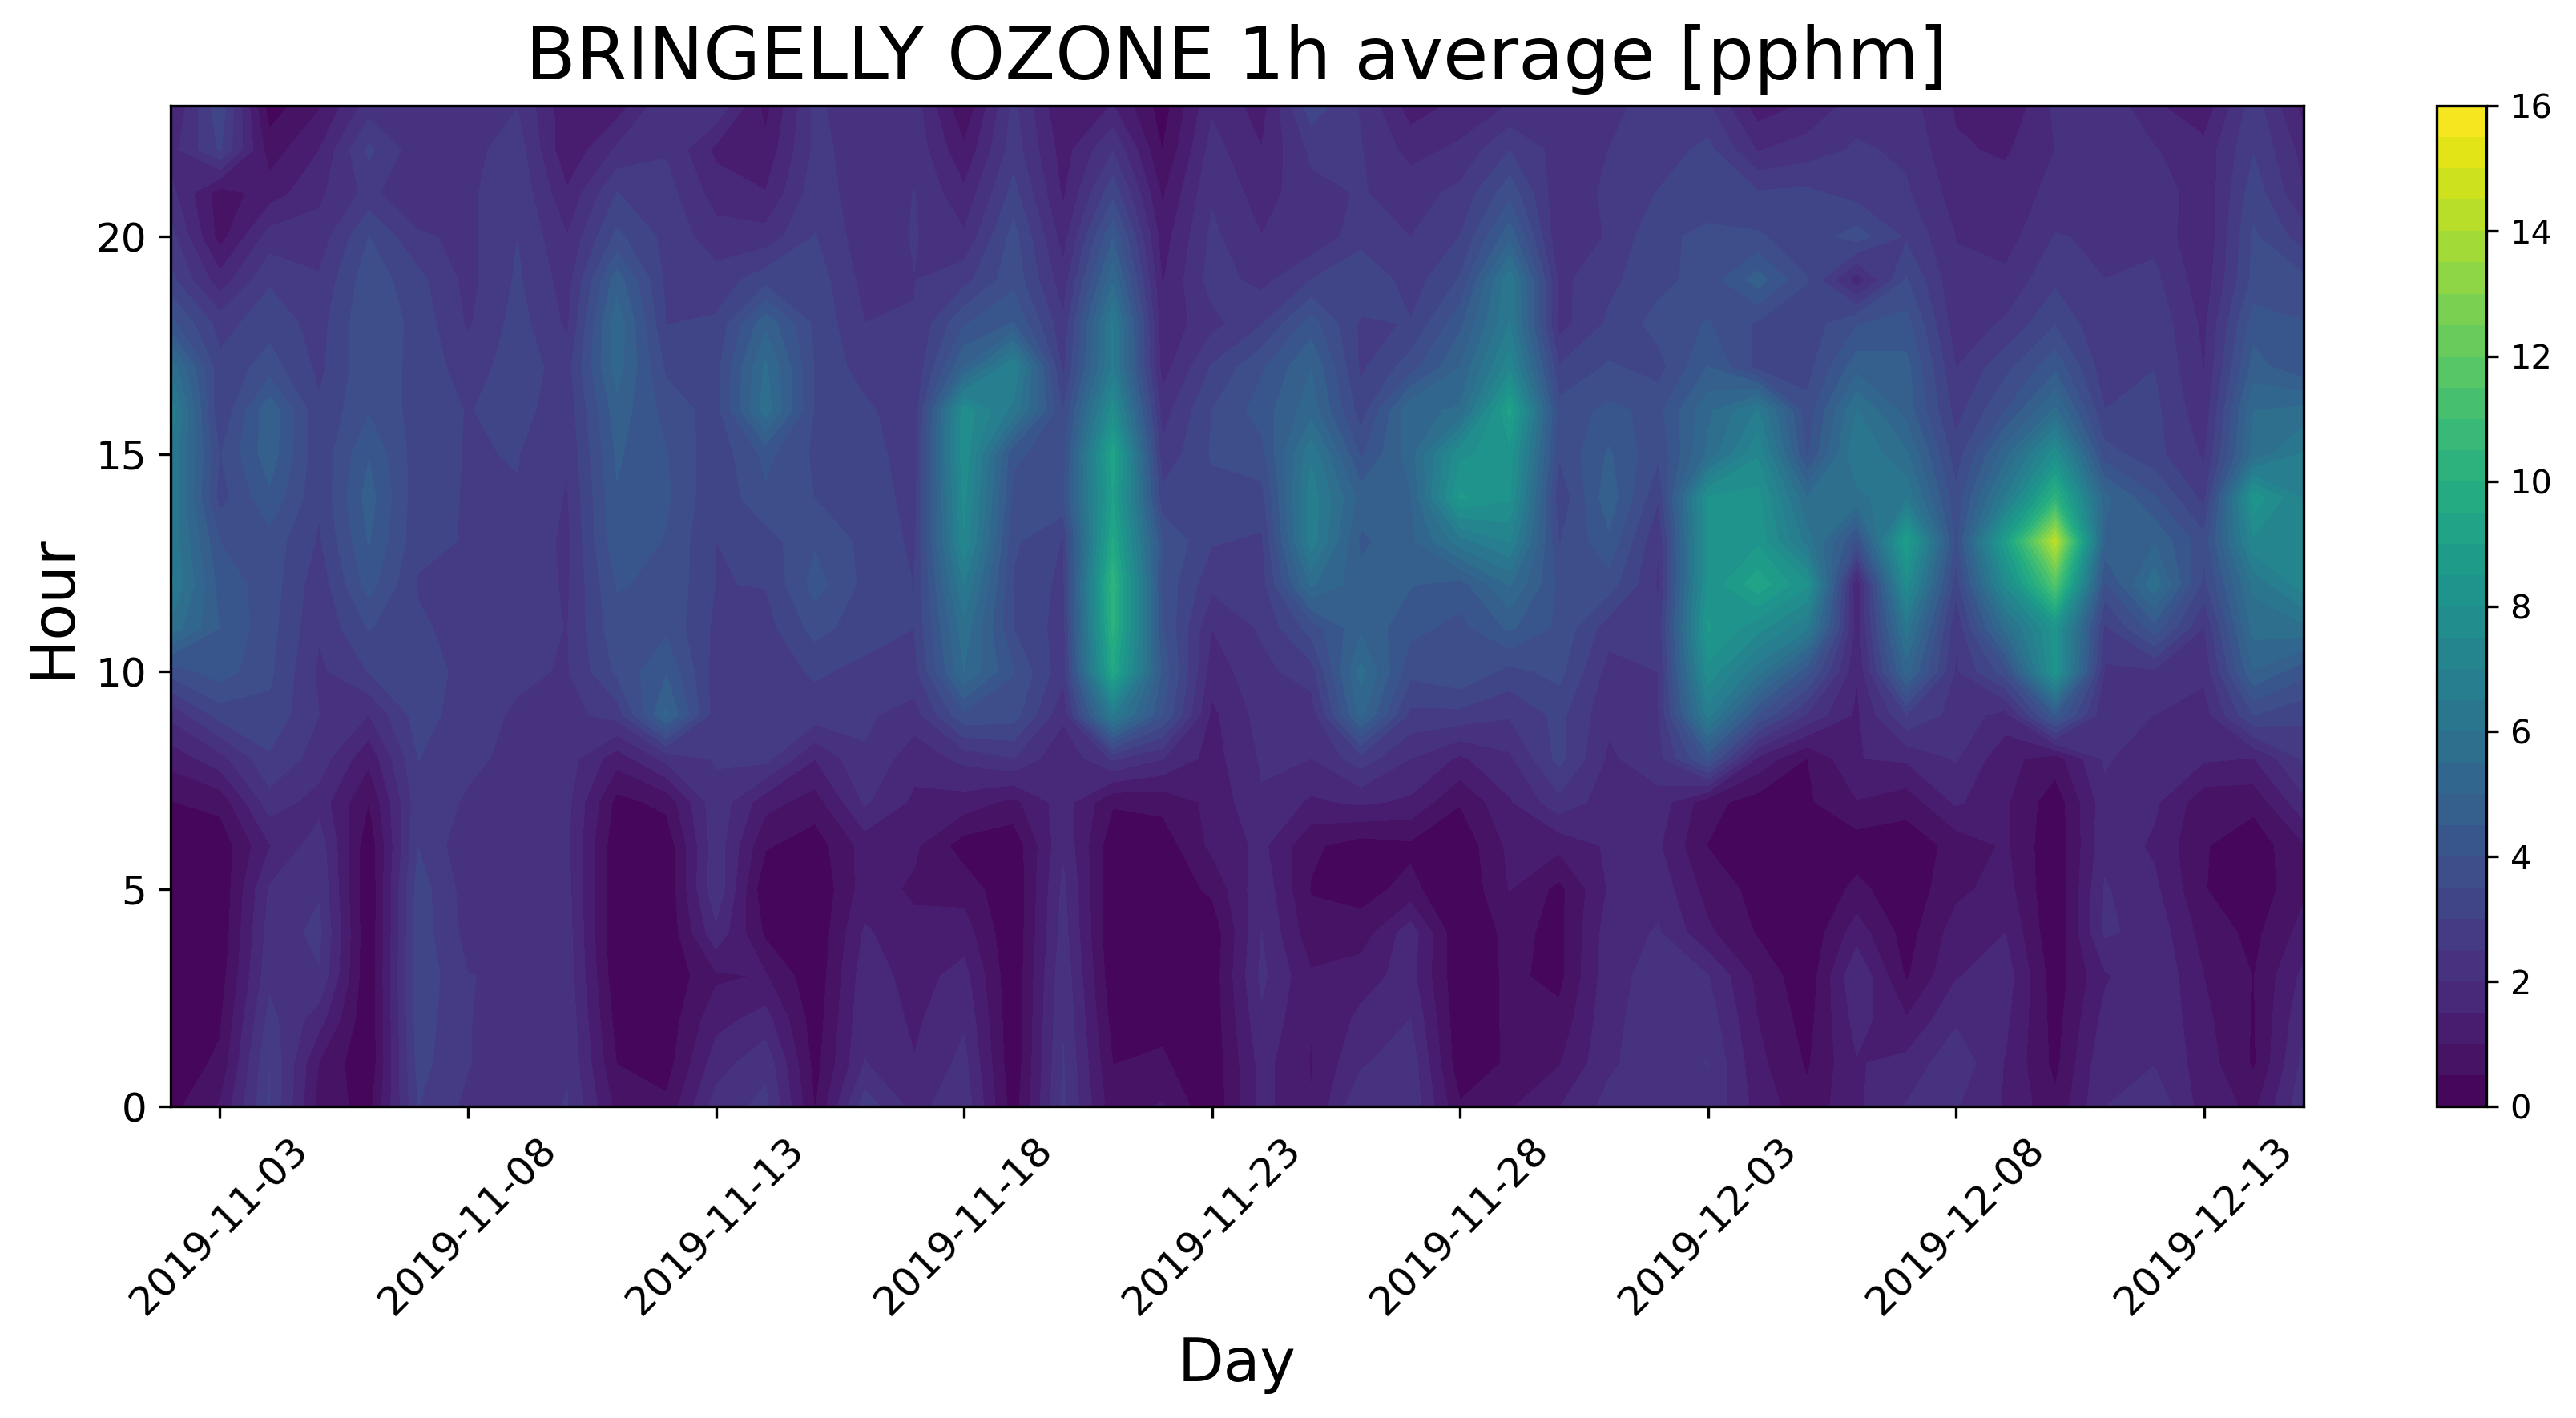

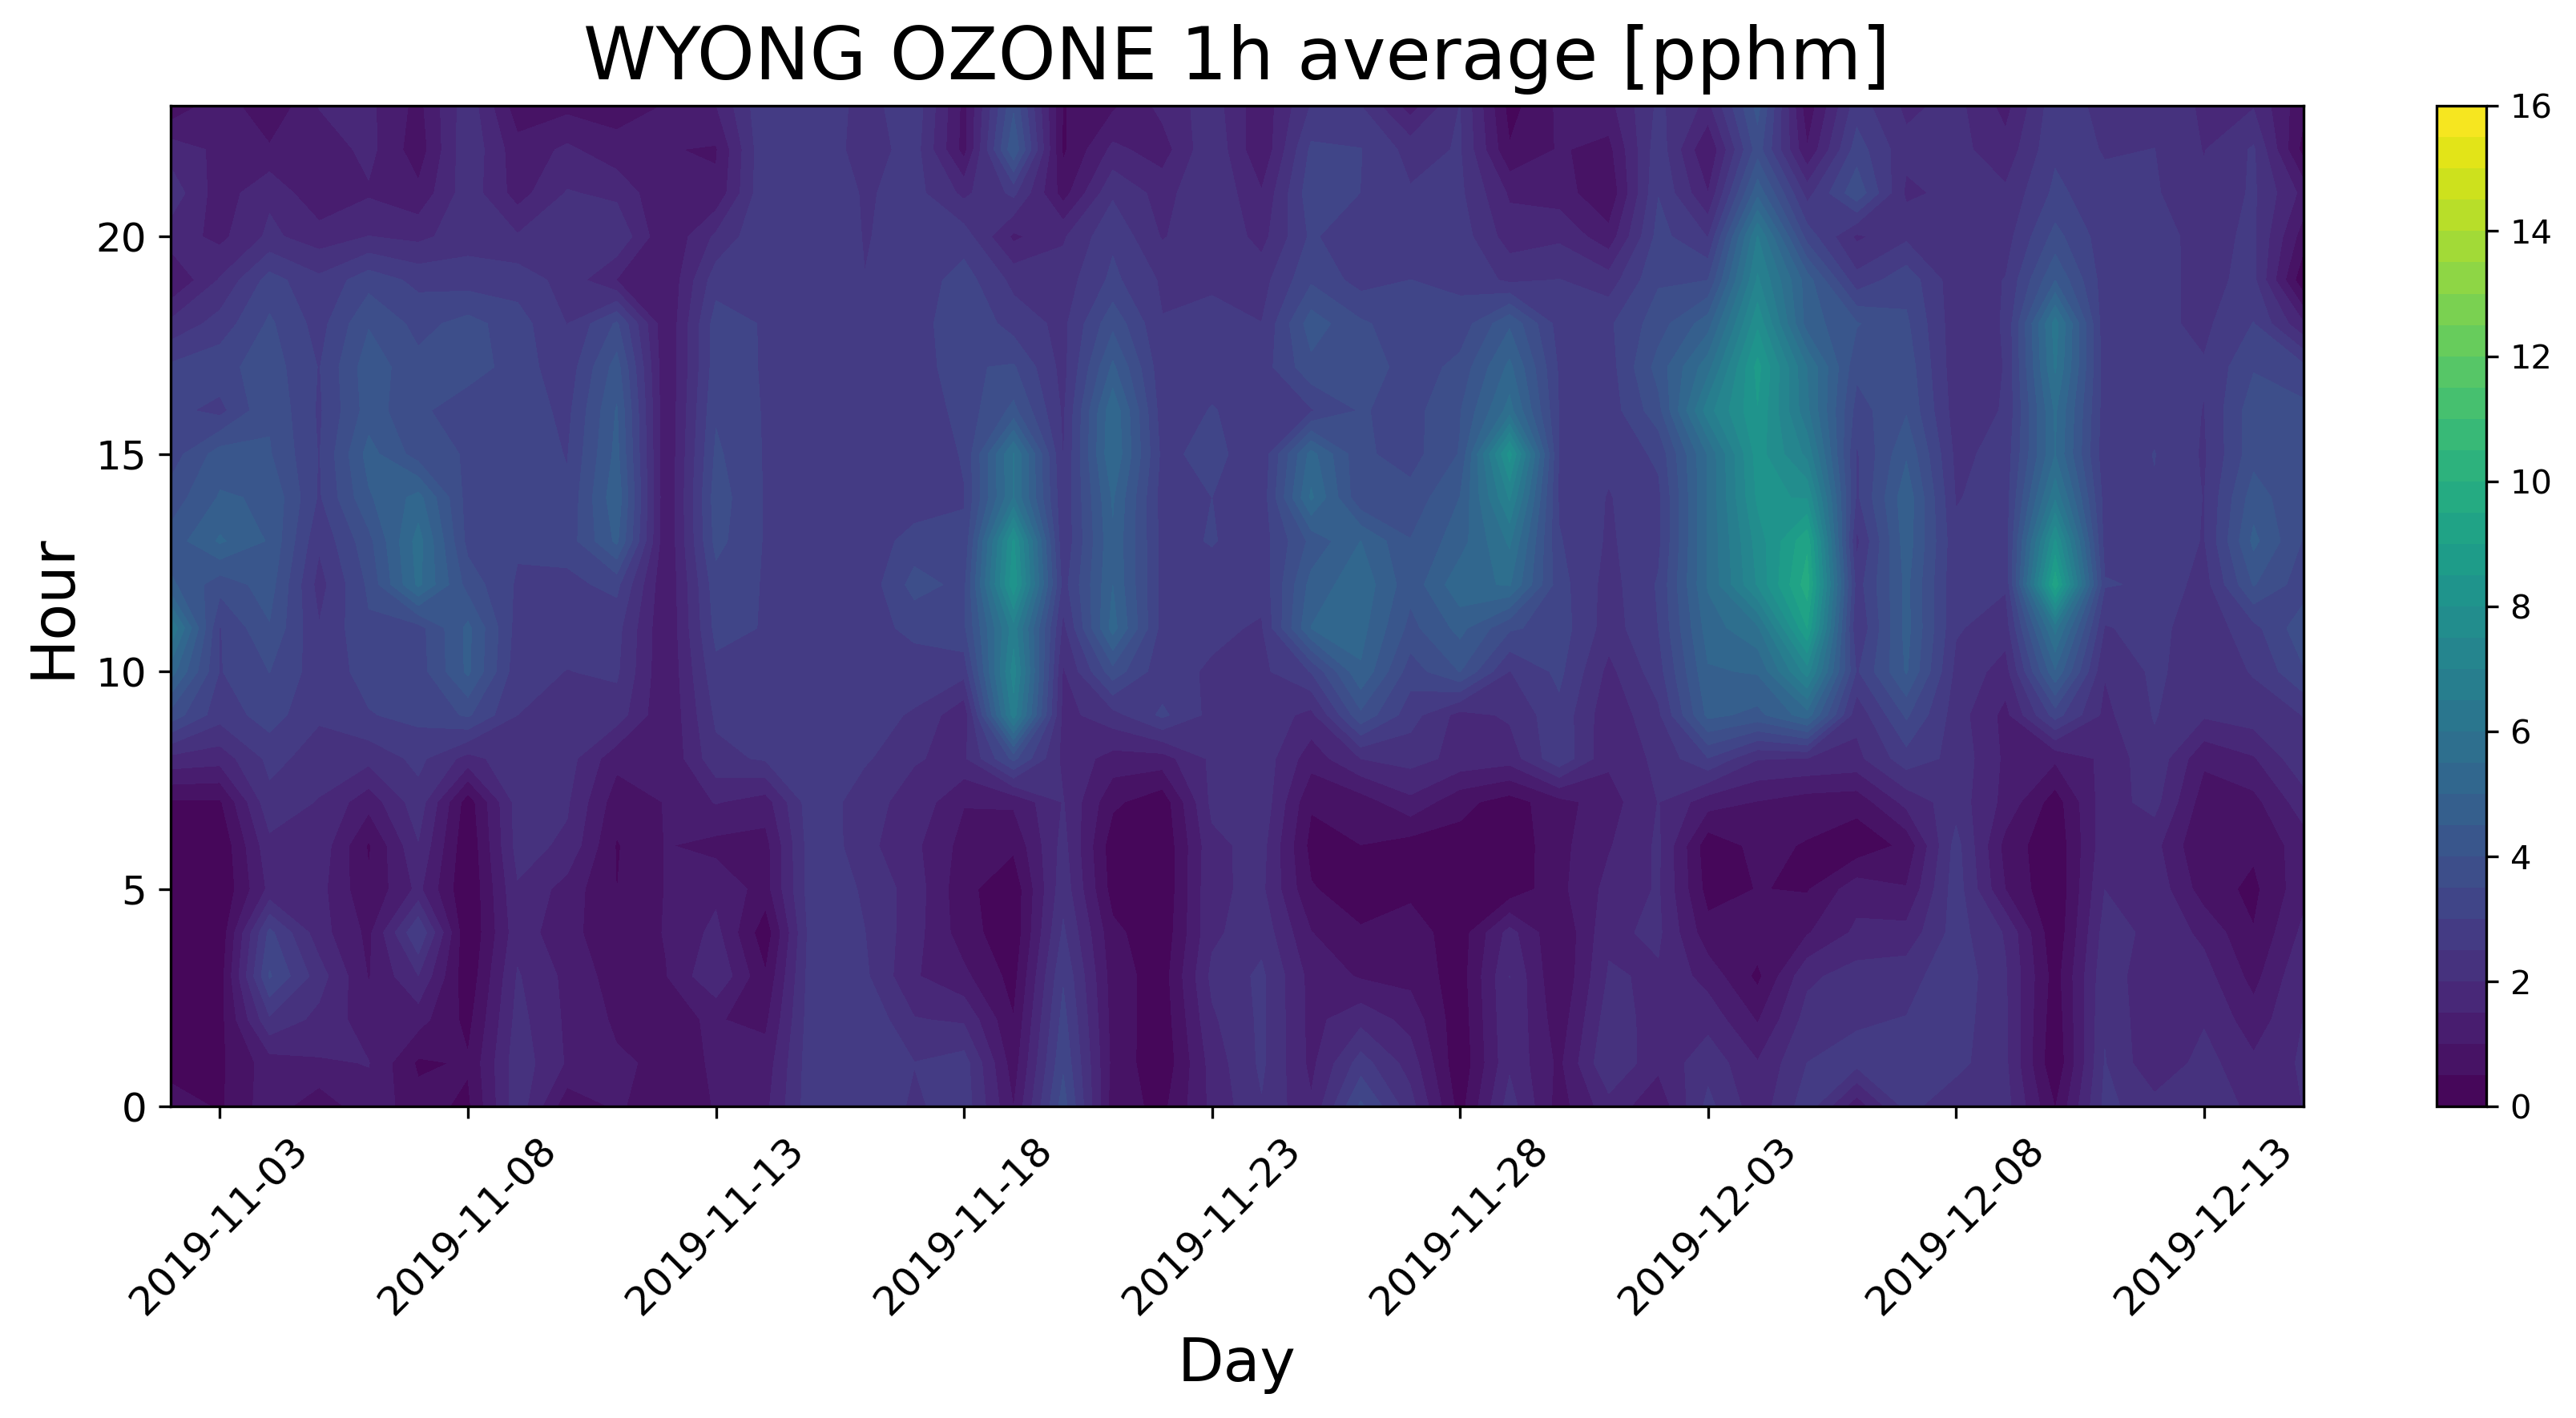

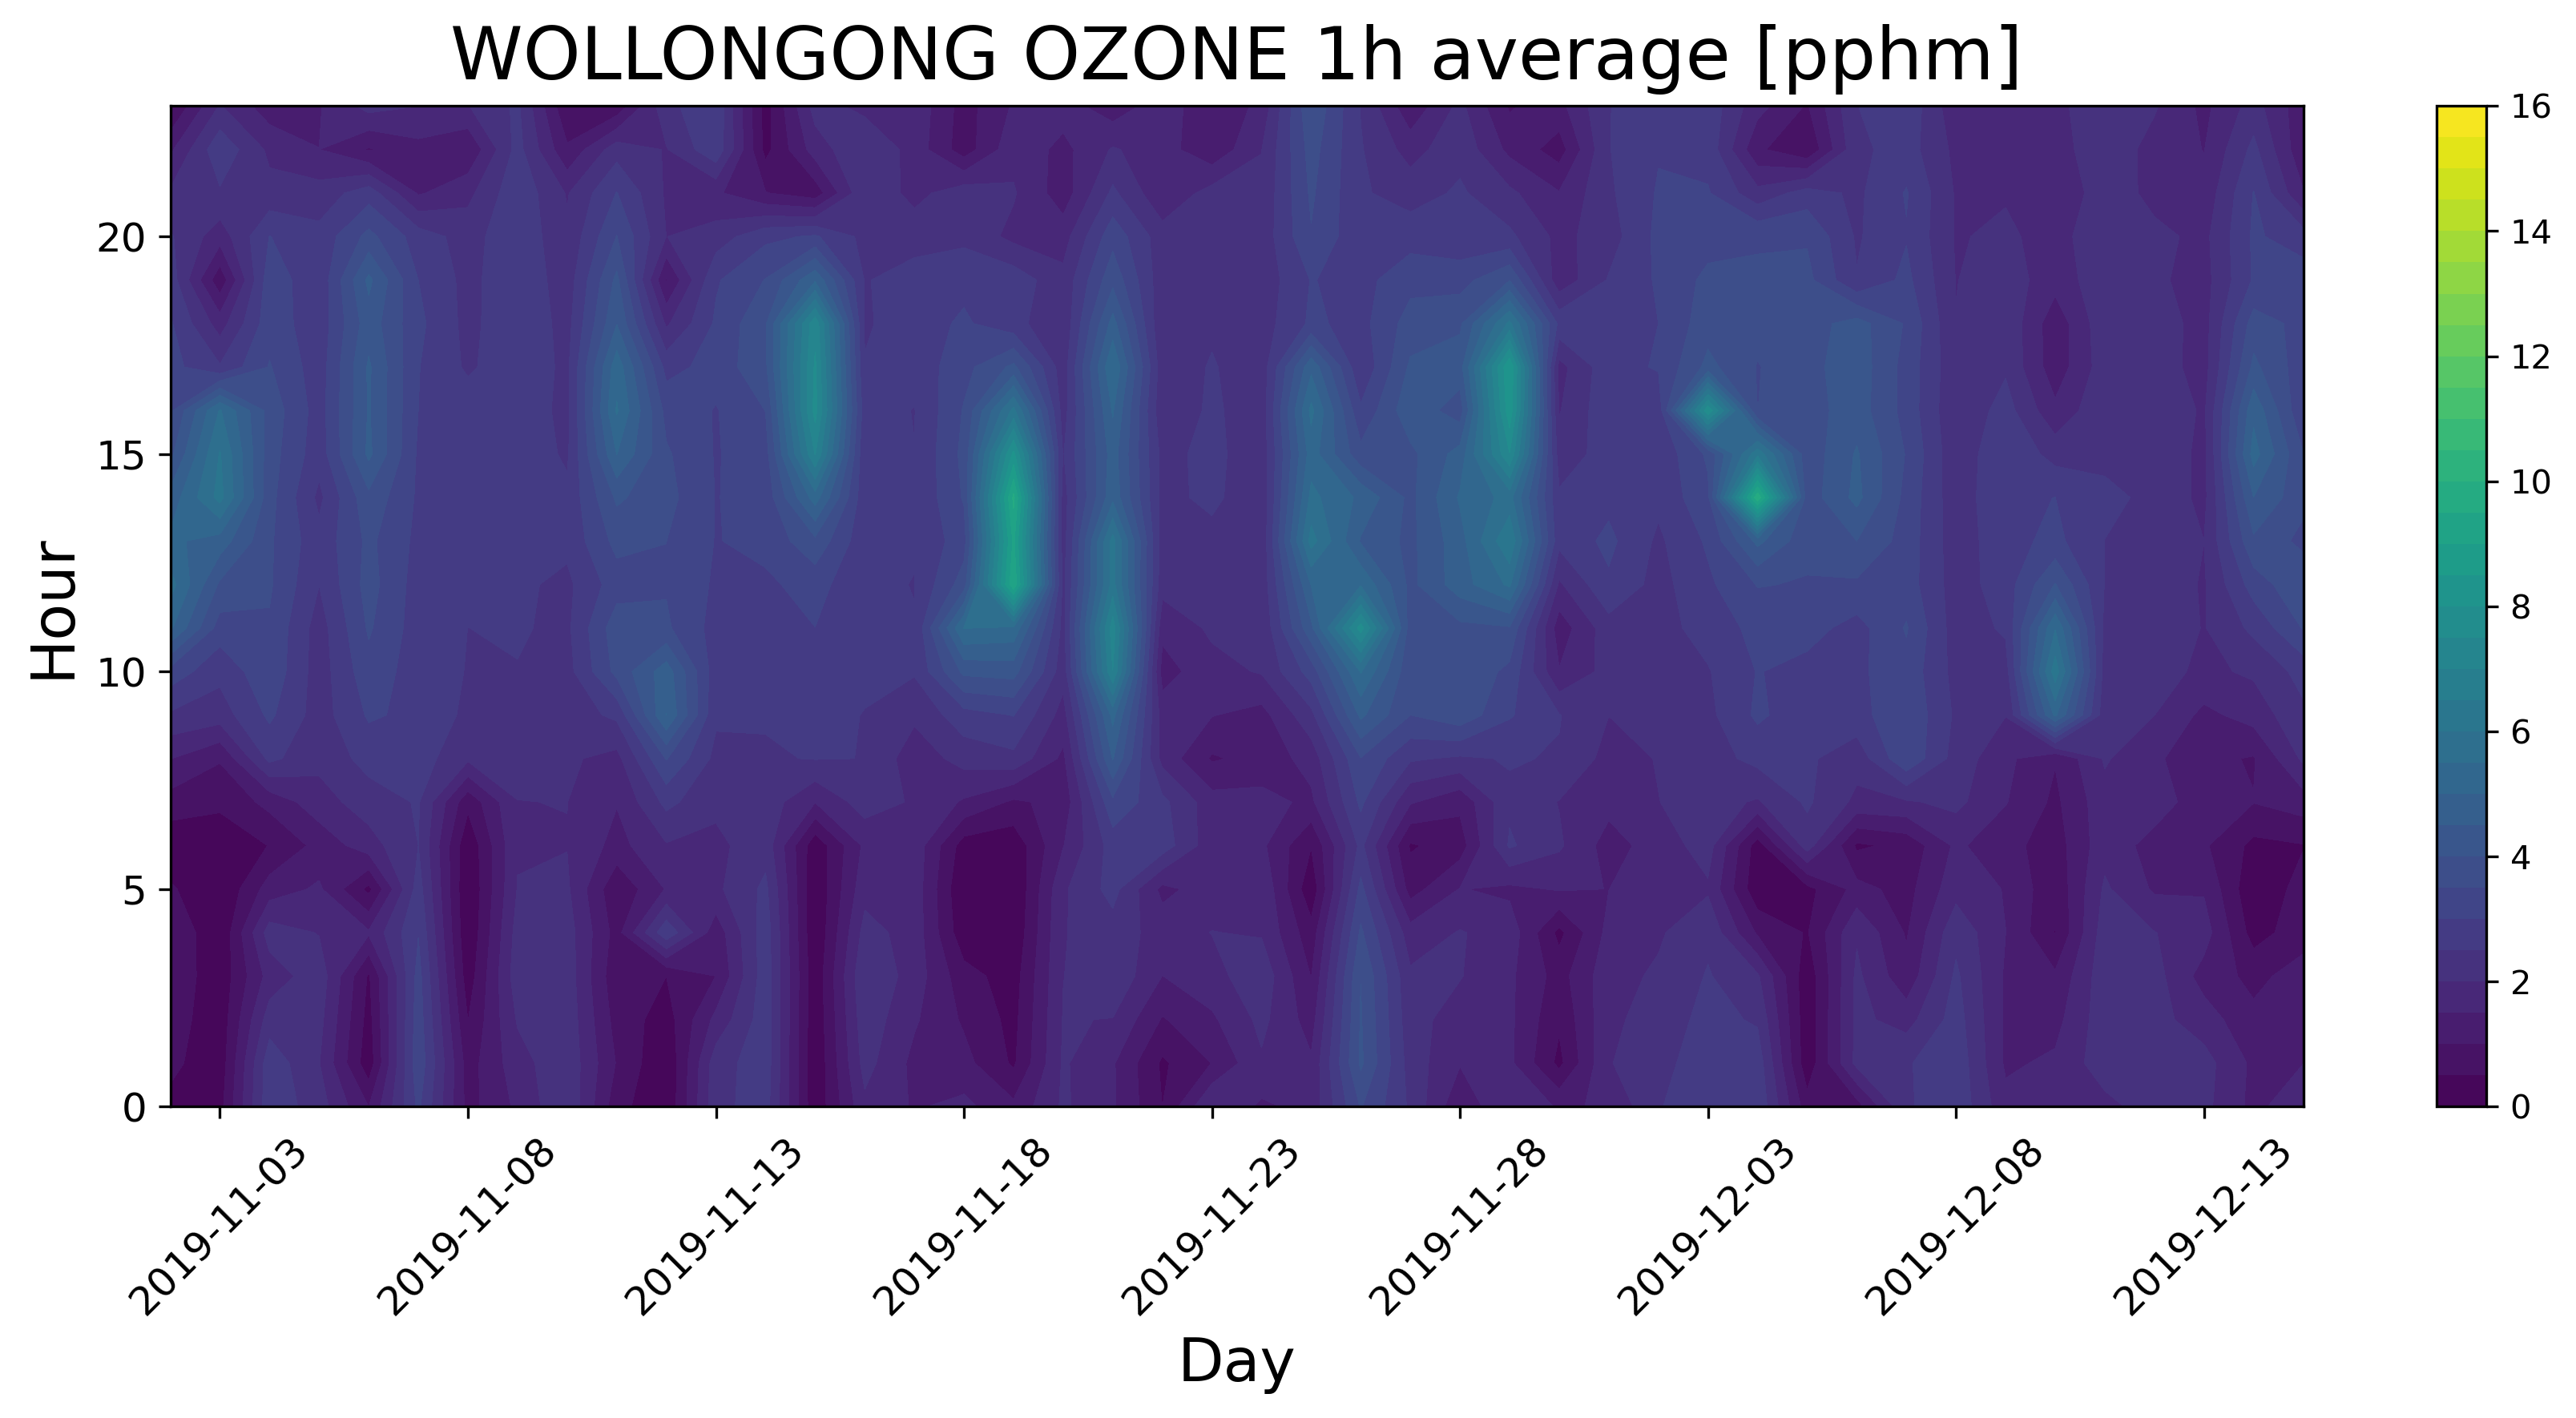

In [220]:
# Adjusting the data selection for the contour plots to the range from 2019-11-02 to 2019-12-15
date_range = pd.date_range(start='2019-11-02 00:00:00', end='2019-12-15 23:00:00', freq='H')
data_filtered = data_interpolated.loc[data_interpolated.index.isin(date_range)]
# Fill missing values
data_filtered = data_filtered.fillna(method='ffill')

# Define the variables and locations
Columns = {
    'NEPH': 'NEPH 1h average [bsp]',
    'PM10': 'PM10 1h average [µg/m³]',
    'PM2.5': 'PM2.5 1h average [µg/m³]',
    'OZONE': 'OZONE 1h average [pphm]'
}
locations = ['BRINGELLY', 'WYONG', 'WOLLONGONG']

# Define contour levels
neph_levels = np.arange(0, 33, 1)
PM10_levels = np.arange(0, 901, 10)
PM25_levels = np.arange(0, 451, 10)
OZONE_levels = np.arange(0, 16.5, 0.5)

# Create a separate figure for each variable at each location
for variable in variables:
    for location in locations:
        # Define the specific variable to plot
        variable_plot = f'{location} {Columns[variable]}'
        # Create a pivot table for the current variable
        pivot_table = data_filtered.pivot_table(values=variable_plot, index=data_filtered.index.hour, columns=data_filtered.index.date, aggfunc=np.mean)
        # Get the meshgrid for the contour plot
        X, Y = np.meshgrid(pivot_table.columns, pivot_table.index)
        Z = pivot_table.values
        # Create the figure and axis
        plt.figure(figsize=(12, 6), dpi=300)
        if variable == 'NEPH':
        # Create the contour plot with specified levels for NEPH
            contour = plt.contourf(X, Y, Z, levels=neph_levels, cmap='viridis', vmin=0, vmax=32, extend=None)
        elif variable == 'PM10':
            contour = plt.contourf(X, Y, Z, levels=PM10_levels, cmap='viridis', vmin=0, vmax=900, extend=None)
        elif variable == 'PM2.5':
            contour = plt.contourf(X, Y, Z, levels=PM25_levels, cmap='viridis', vmin=0, vmax=450, extend=None)
        elif variable == 'OZONE':
            contour = plt.contourf(X, Y, Z, levels=OZONE_levels, cmap='viridis', vmin=0, vmax=16, extend=None)
        plt.title(f'{variable_plot}',fontsize=22, pad=8)
        plt.xlabel('Day', fontsize=18)
        plt.ylabel('Hour', fontsize=18)
        # Formatting the x-axis to show the date properly
        plt.xticks(rotation=45, fontsize=12)
        plt.yticks(fontsize=12)
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
        # Add a color bar to the plot
        plt.colorbar(contour)
        # Show the plot
        plt.tight_layout()
        plt.show()

### Pollution Data Distribution

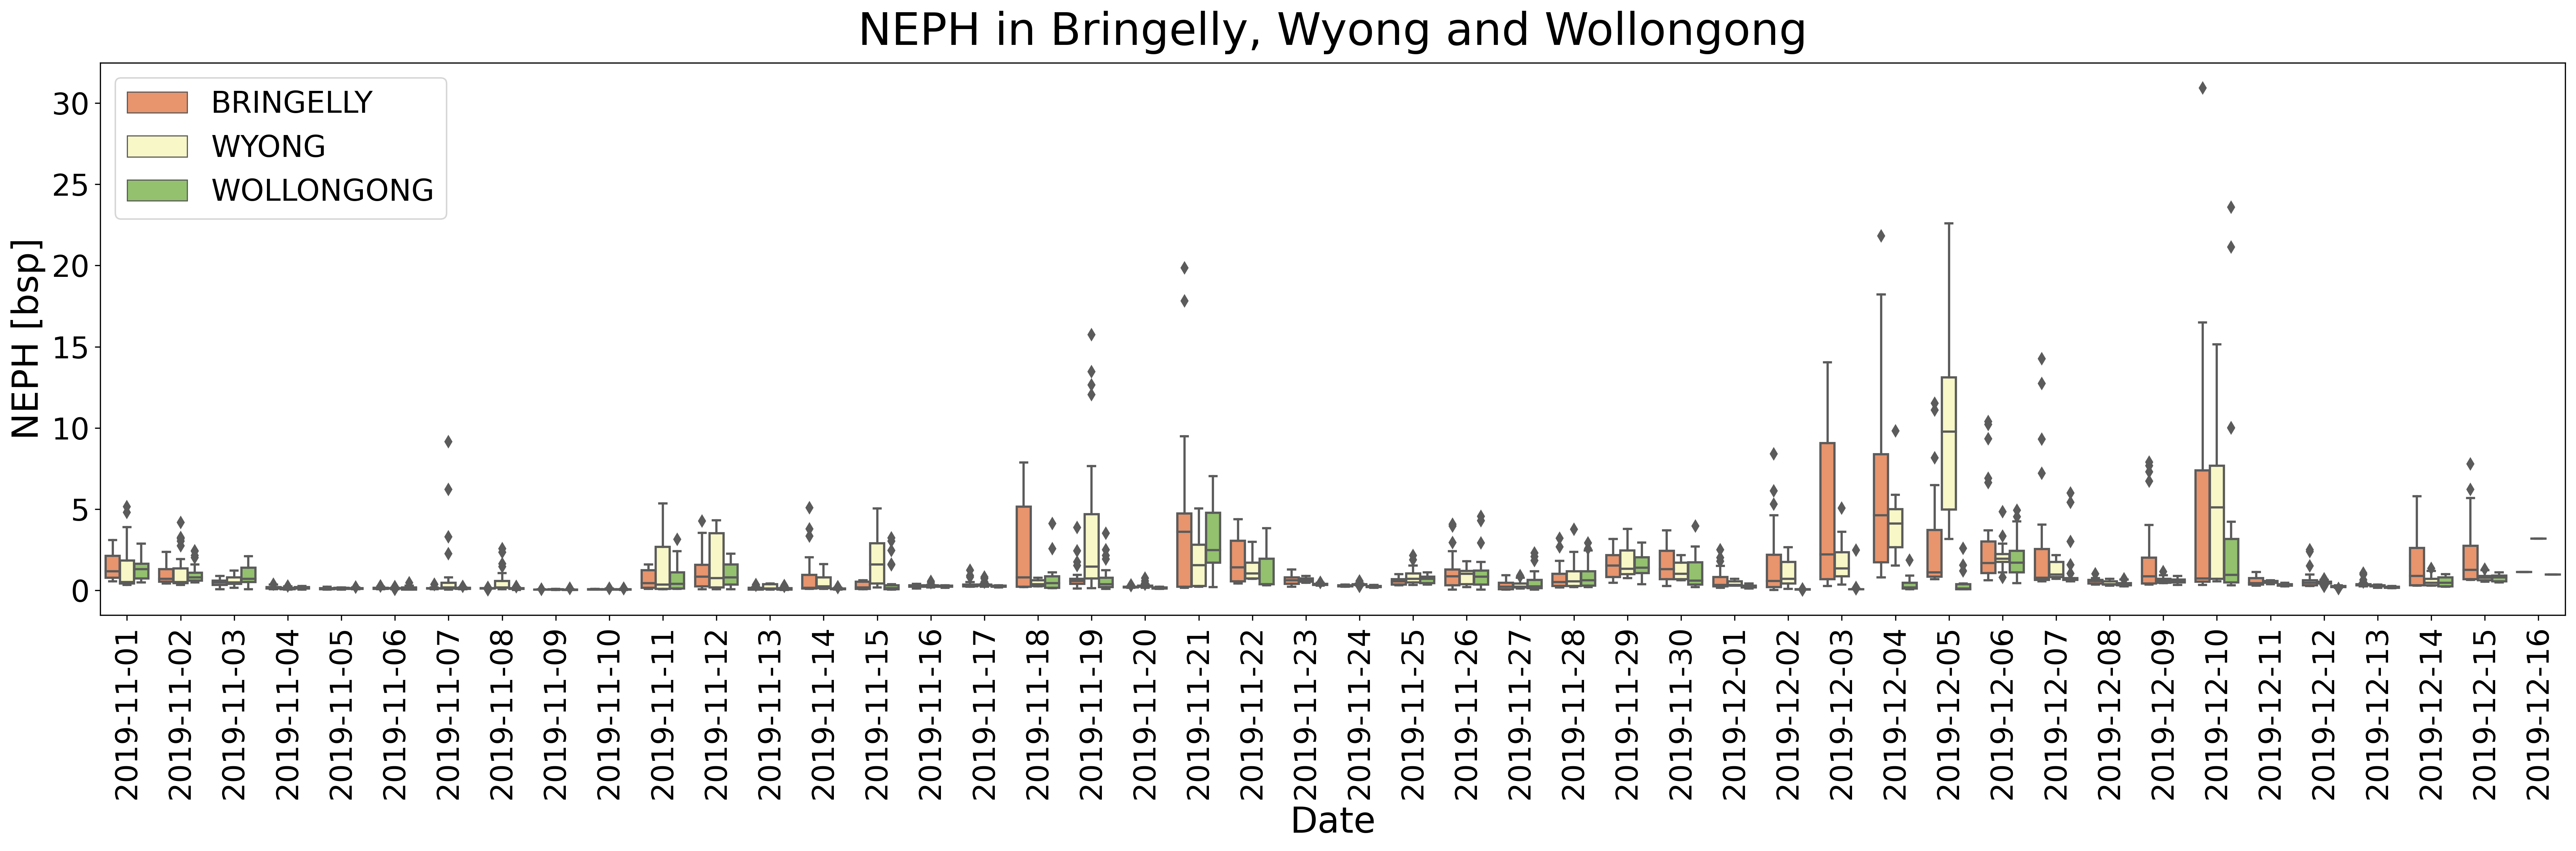

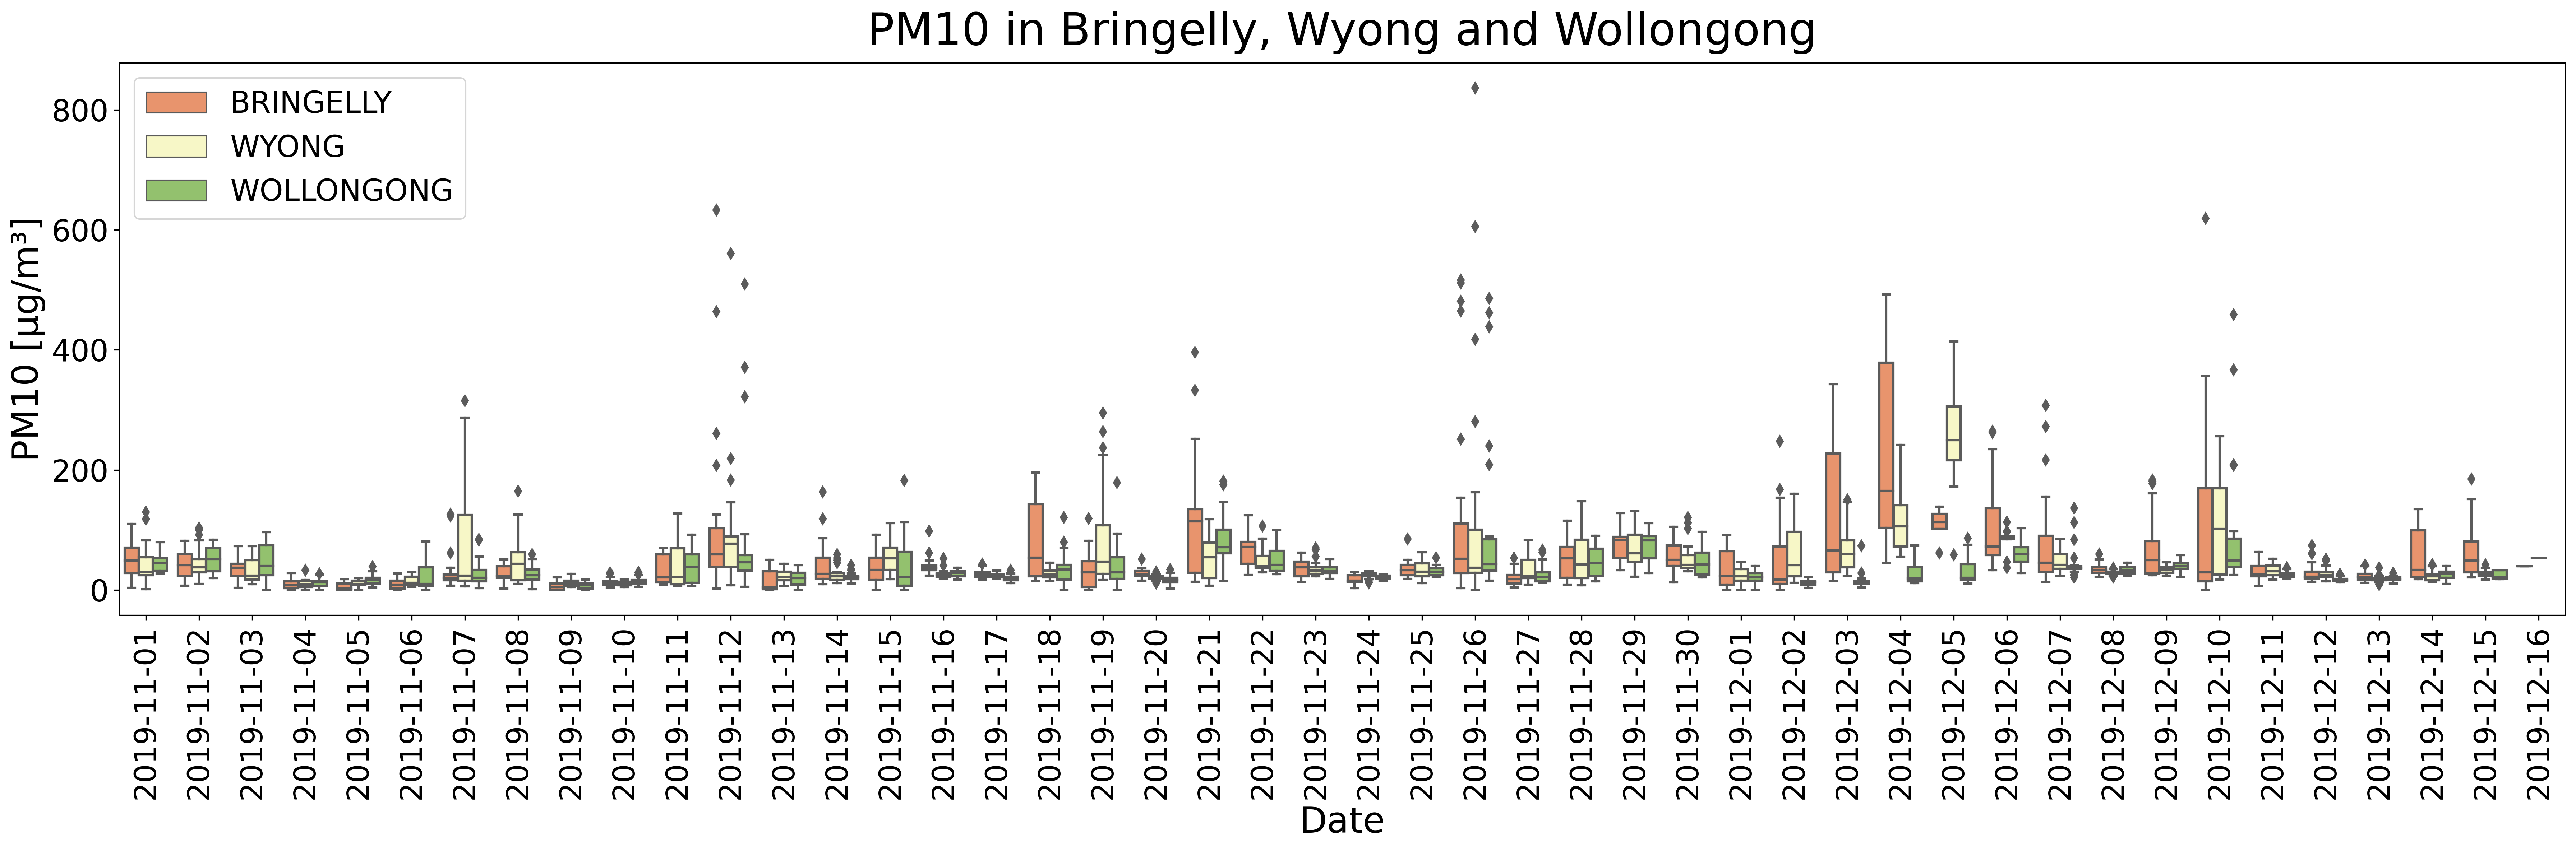

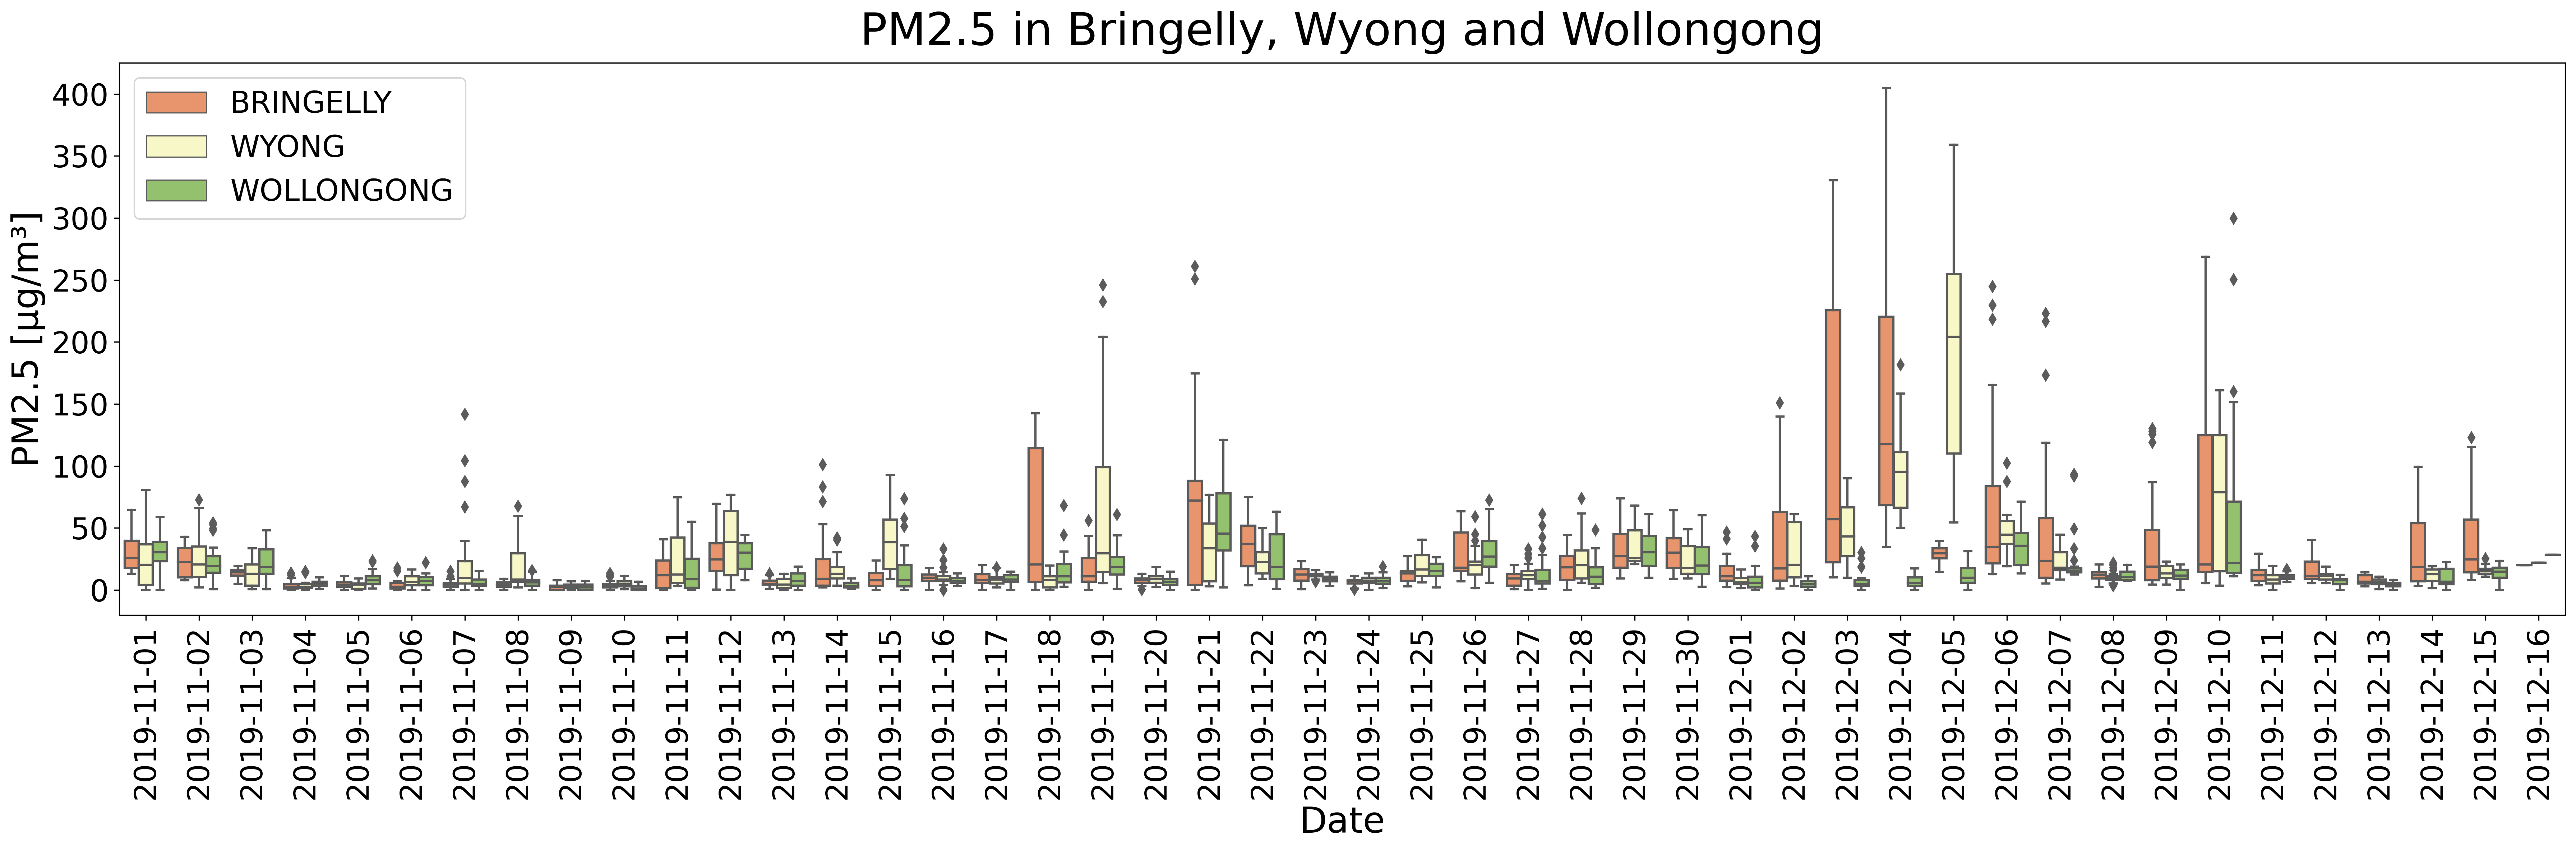

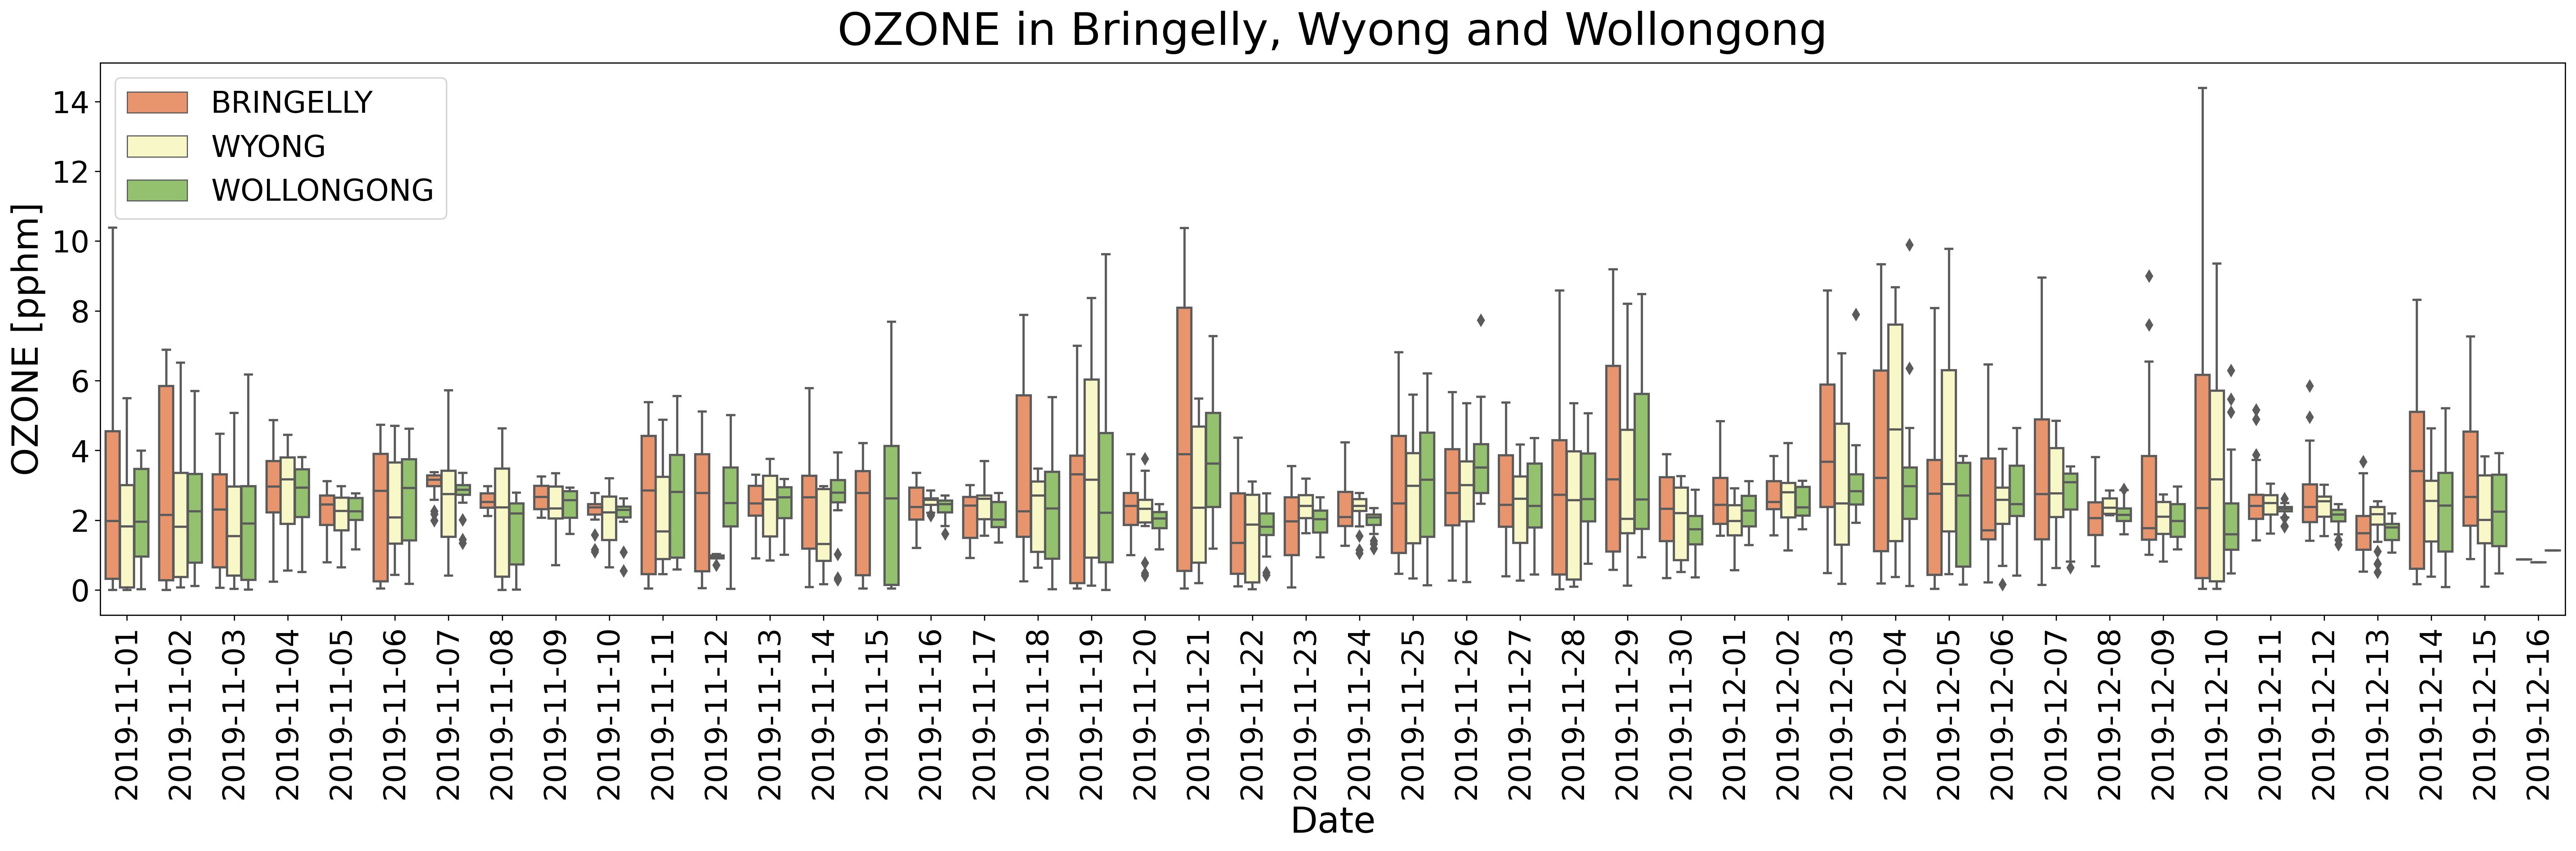

In [157]:
# Create a box plot for each pollutant variable

# Define the variables and locations
columns = {
    'NEPH': 'NEPH 1h average [bsp]',
    'PM10': 'PM10 1h average [µg/m³]',
    'PM2.5': 'PM2.5 1h average [µg/m³]',
    'OZONE': 'OZONE 1h average [pphm]'
}

locations = ['BRINGELLY', 'WYONG', 'WOLLONGONG']

units = {
    'NEPH': 'bsp',
    'PM10': 'µg/m³',
    'PM2.5': 'µg/m³',
    'OZONE': 'pphm'
}

# Define a dictionary with colors for each location
my_palette = {'BRINGELLY': '#fc8d59', 'WYONG': '#ffffbf', 'WOLLONGONG': '#91cf60'}

for variable in variables:
    # Get the correct column names
    column_names = [f'{location} {columns[variable]}' for location in locations]
    plot_data = data_interpolated[column_names].copy()
    # Add a 'Date' column to the data for plotting
    plot_data['Date'] = data_interpolated.index.date
    # Melt the data keeping the 'Date' column intact
    plot_data = plot_data.melt(id_vars='Date', var_name='Location', value_name=variable)
    # Replace full column names with just the location names
    plot_data['Location'] = plot_data['Location'].str.extract(r'(^.*?)\s')

    # Create the box plot
    plt.figure(figsize=(24, 8), dpi=300)
    sns.boxplot(x='Date', y=variable, hue='Location', data=plot_data, palette=my_palette)
    plt.xticks(rotation=90, fontsize=20)
    plt.yticks(fontsize=20)
    plt.title(f'{variable} in Bringelly, Wyong and Wollongong', fontsize=30, pad=12)
    plt.xlabel('Date', fontsize=24)
    plt.ylabel(f'{variable} [{units[variable]}]', fontsize=24)
    plt.legend(fontsize=20, loc='upper left')
    plt.tight_layout()
    plt.show()

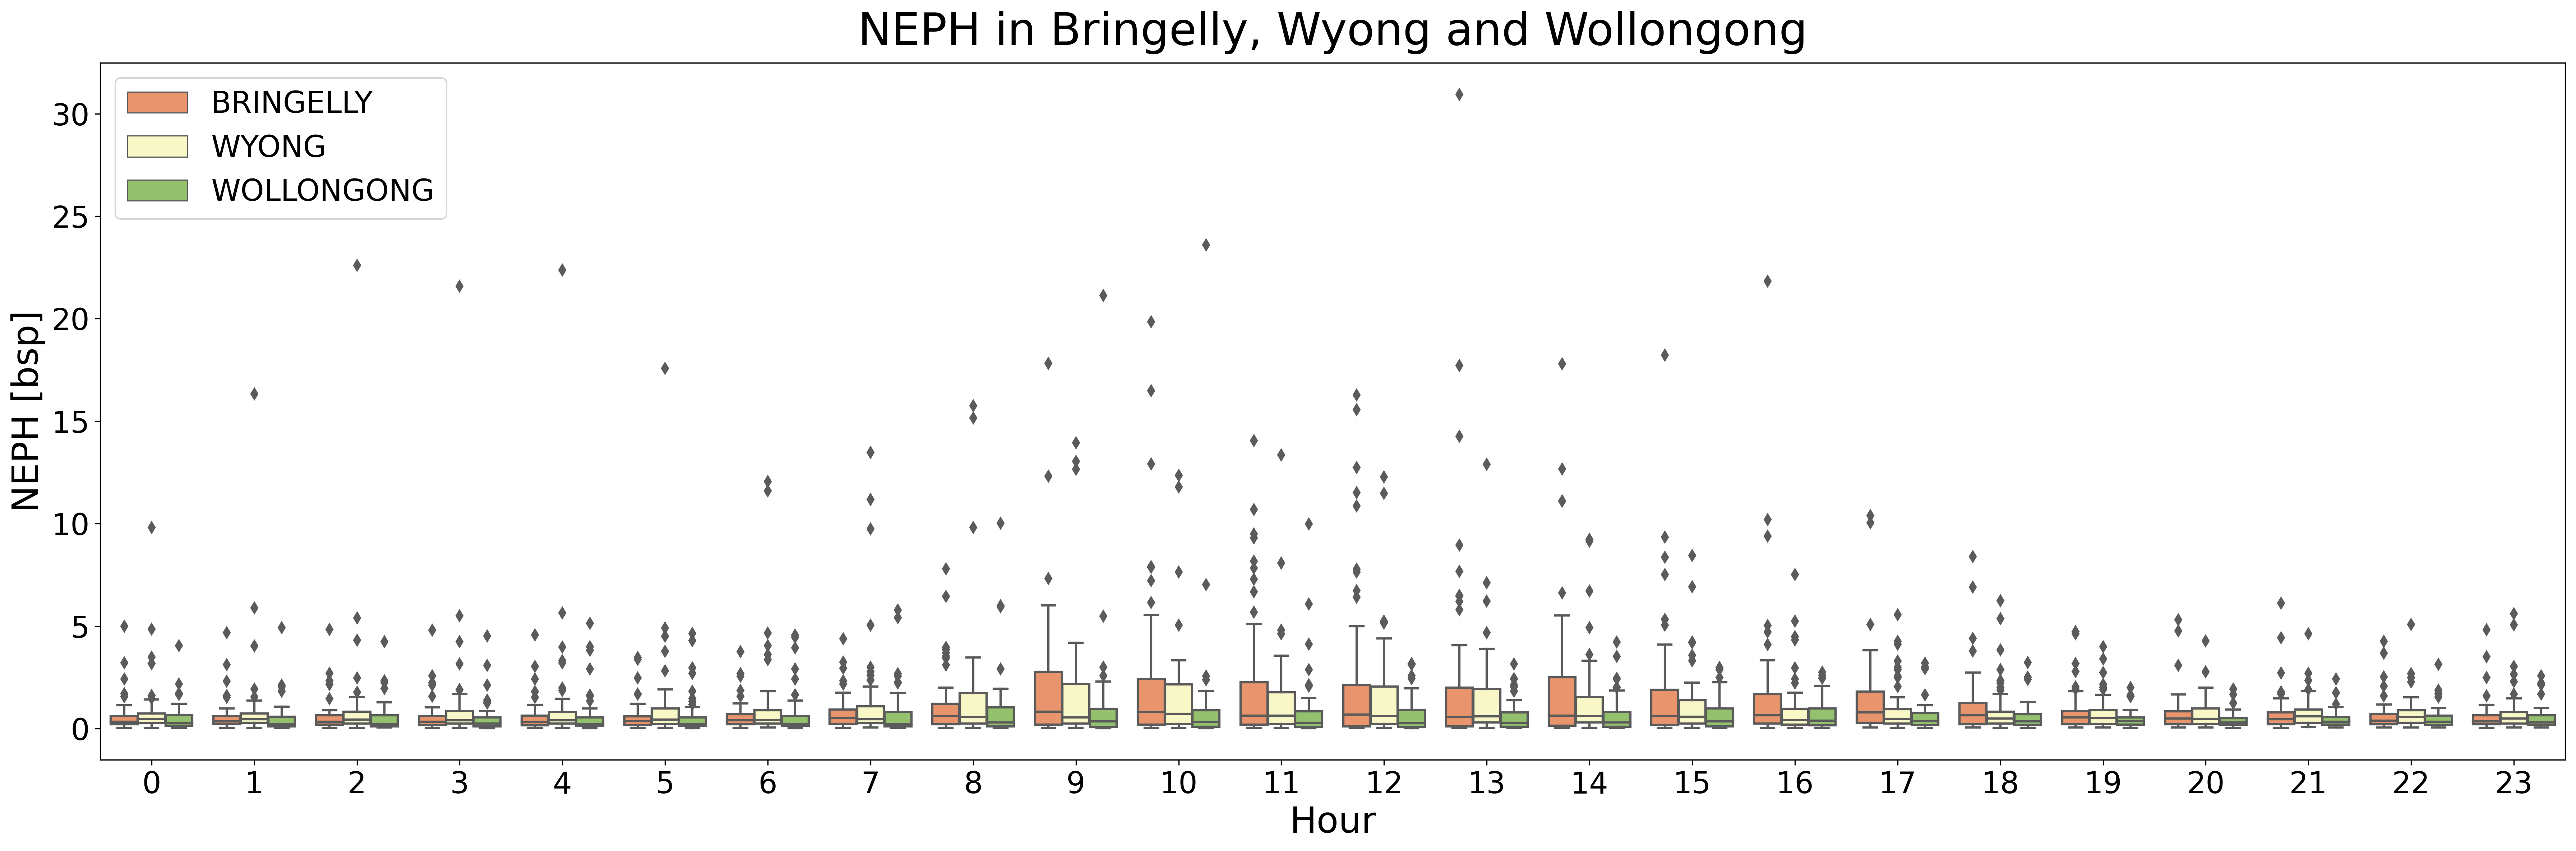

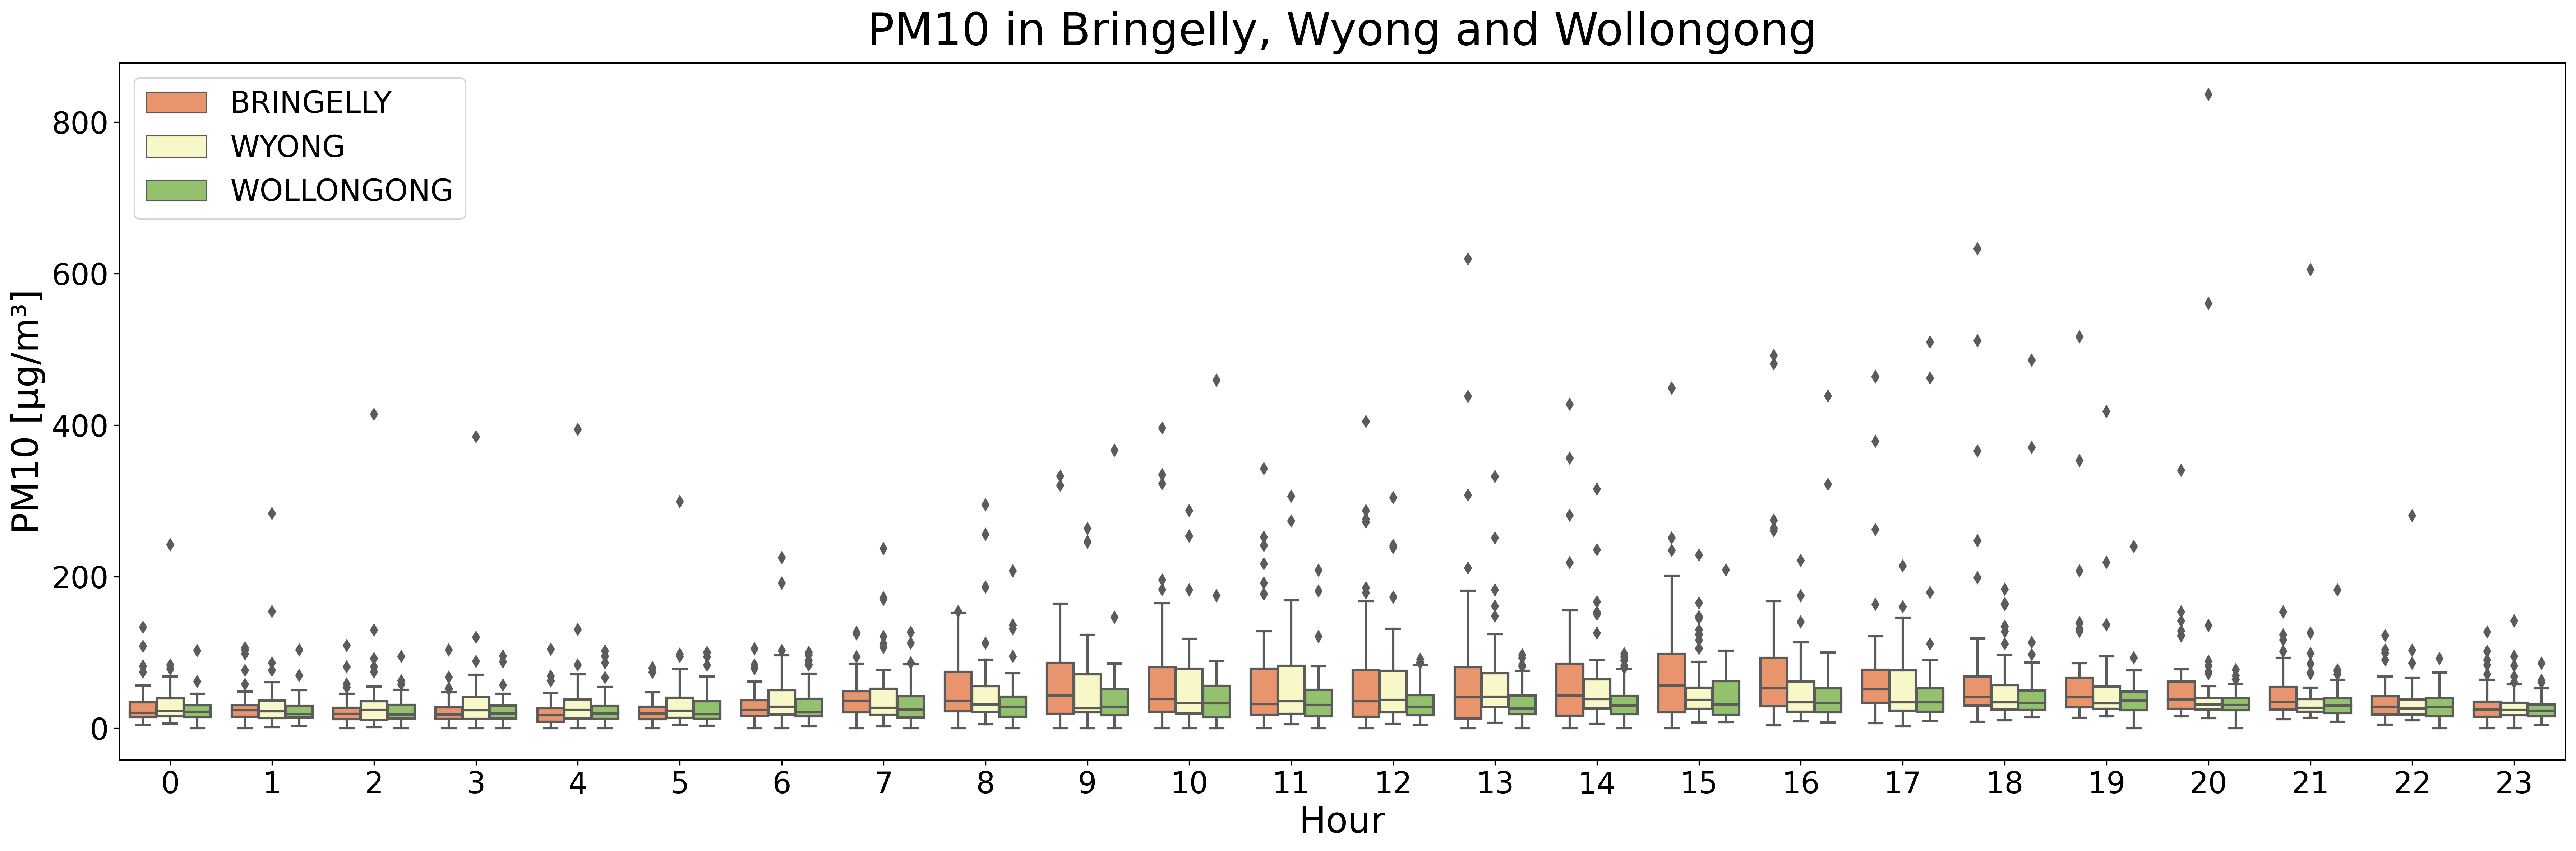

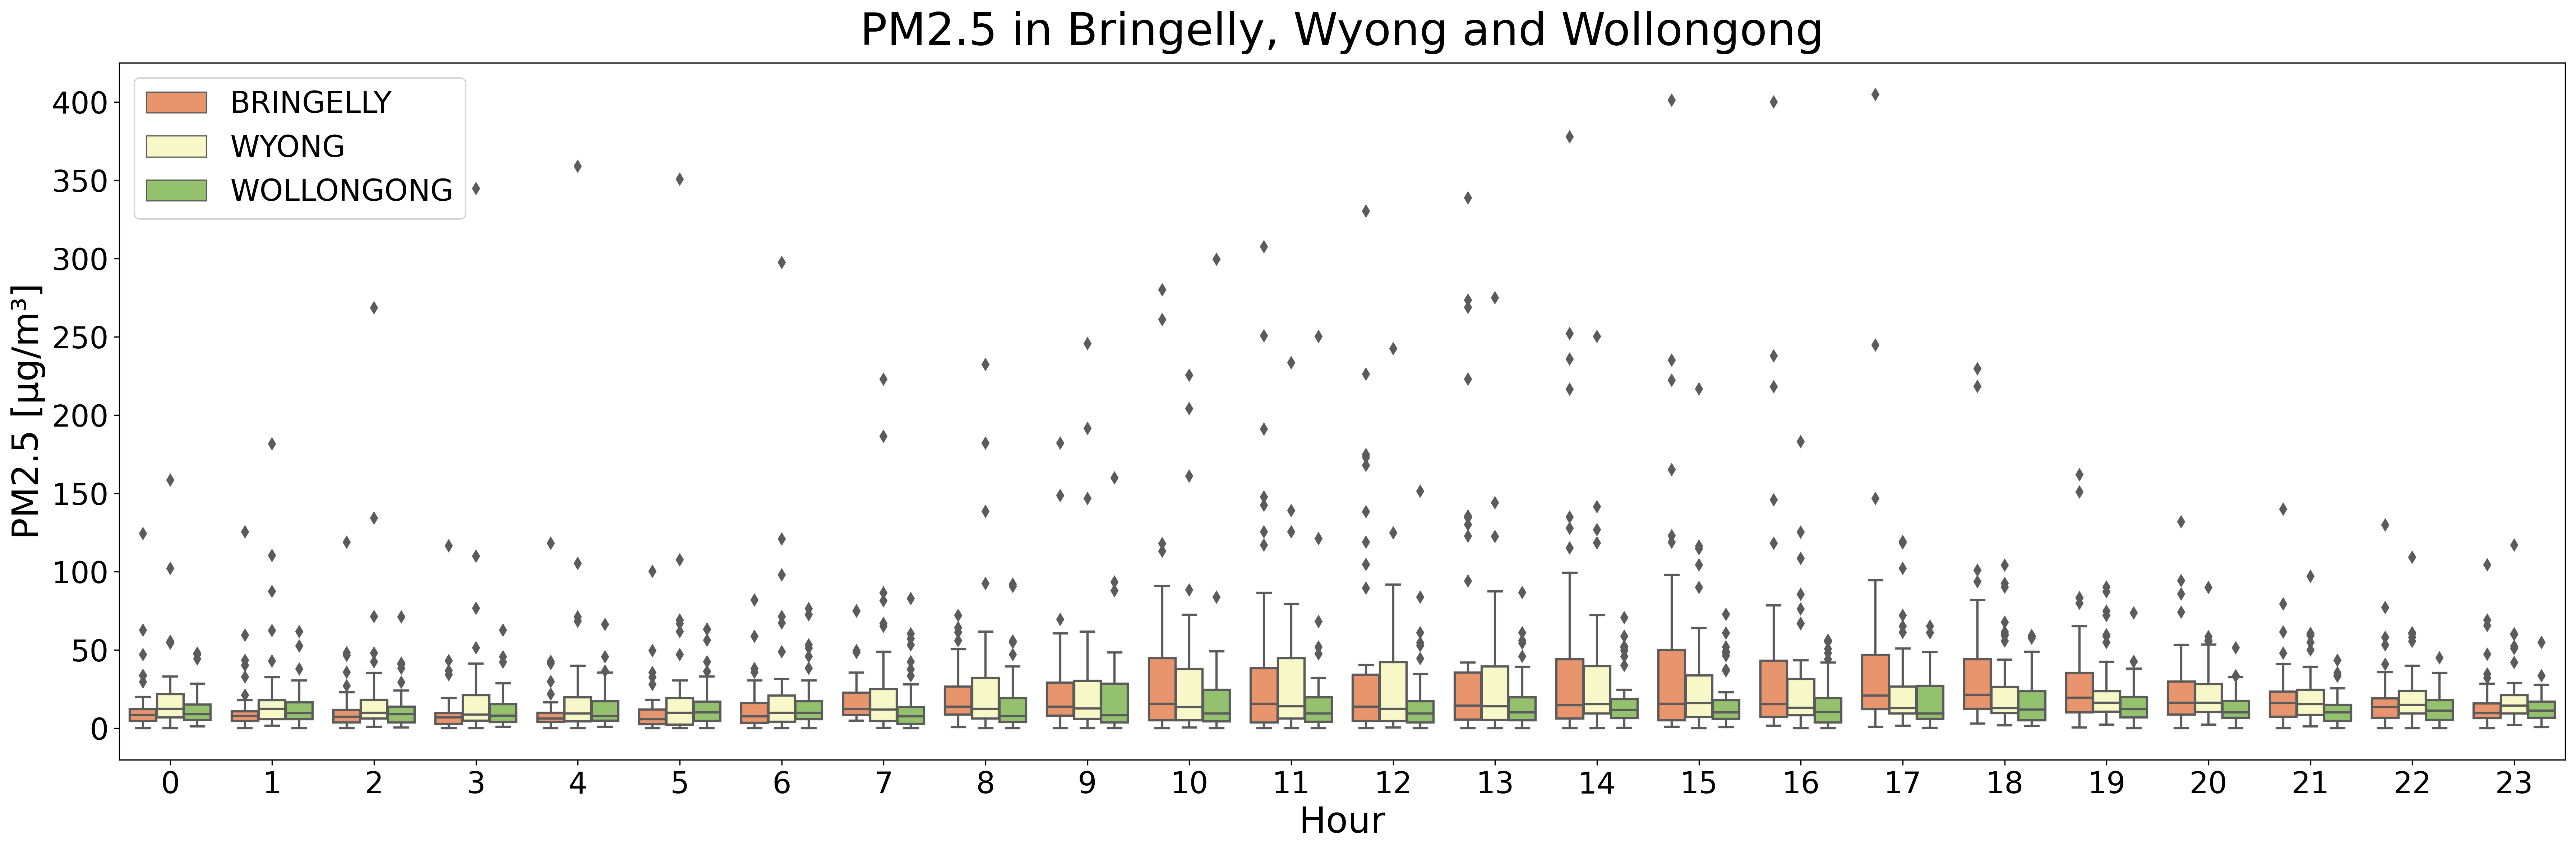

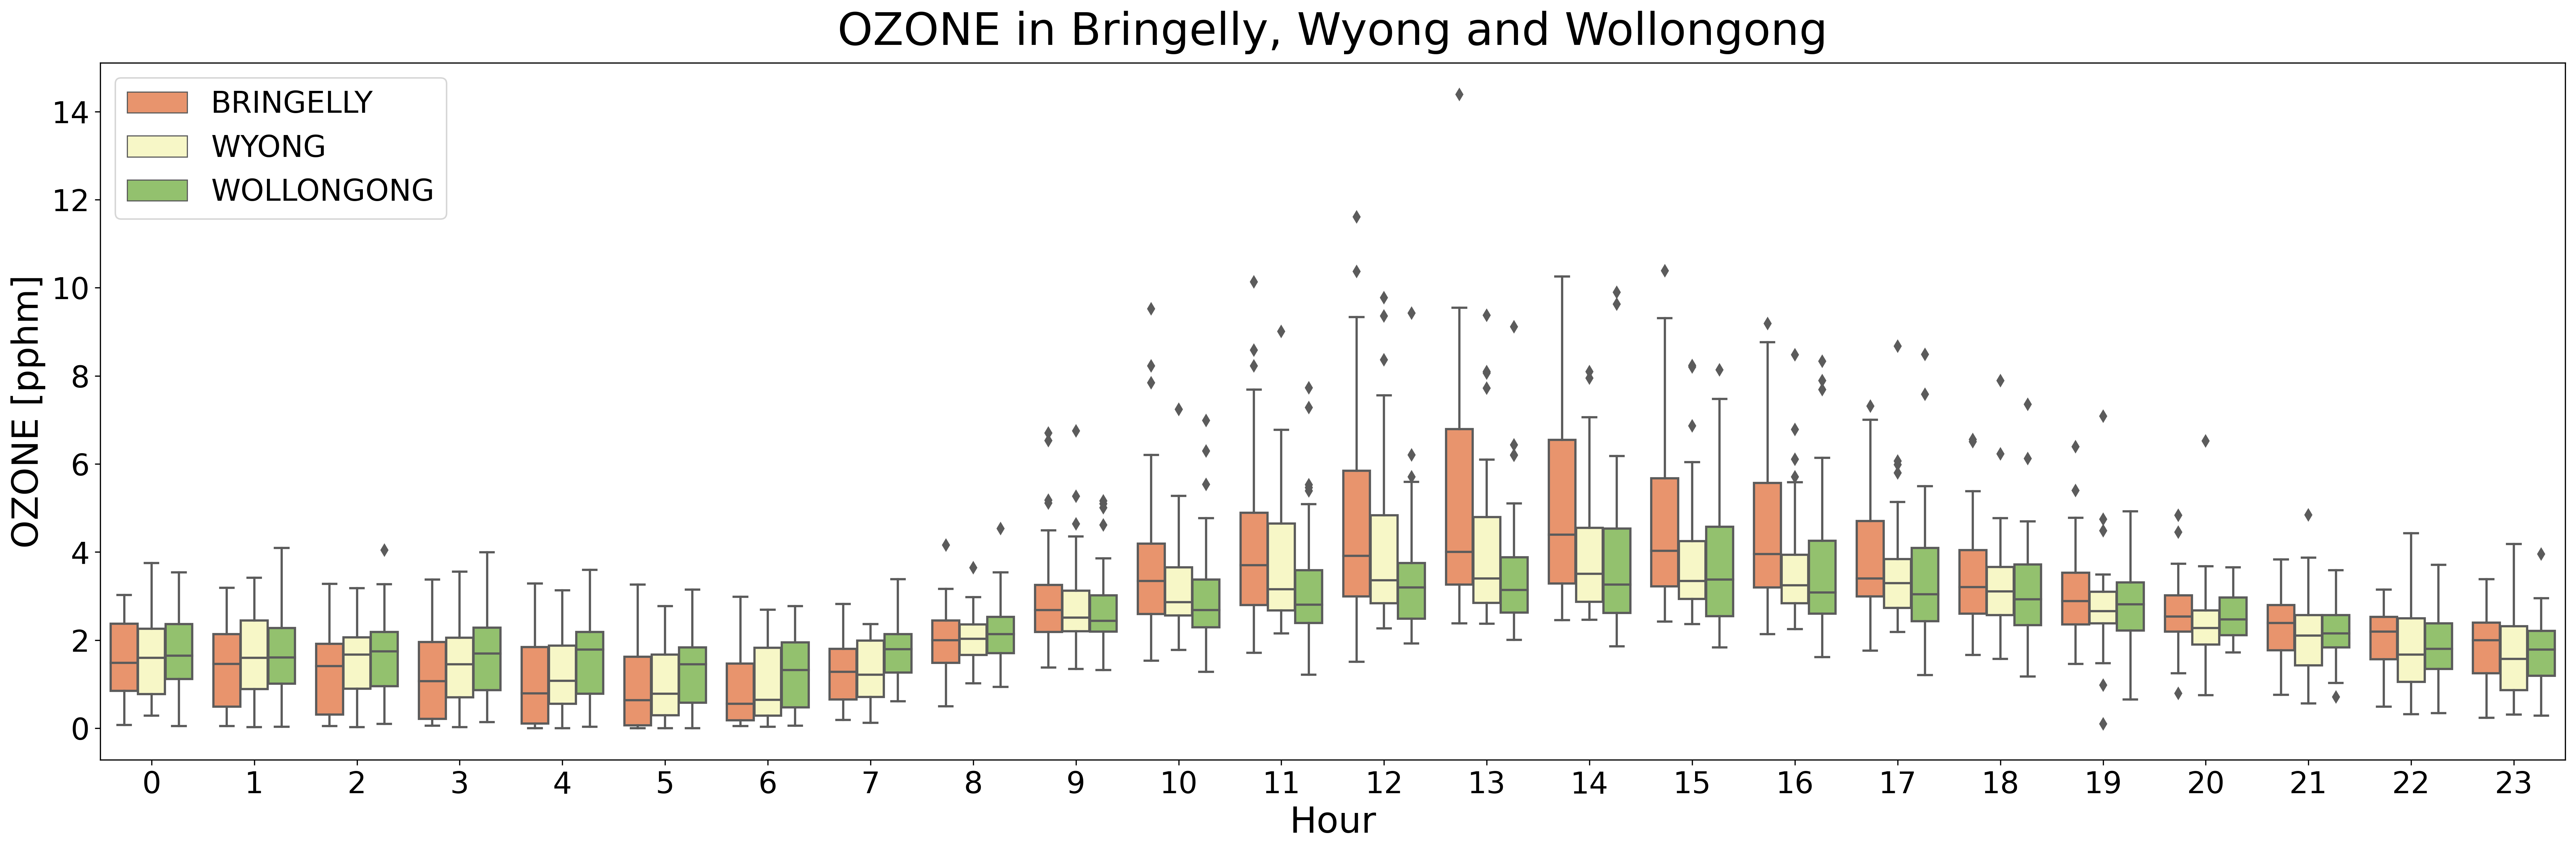

In [219]:
# Define the variables and locations
columns = {
    'NEPH': 'NEPH 1h average [bsp]',
    'PM10': 'PM10 1h average [µg/m³]',
    'PM2.5': 'PM2.5 1h average [µg/m³]',
    'OZONE': 'OZONE 1h average [pphm]'
}

locations = ['BRINGELLY', 'WYONG', 'WOLLONGONG']

units = {
    'NEPH': 'bsp',
    'PM10': 'µg/m³',
    'PM2.5': 'µg/m³',
    'OZONE': 'pphm'
}

# Define a dictionary with colors for each location
my_palette = {'BRINGELLY': '#fc8d59', 'WYONG': '#ffffbf', 'WOLLONGONG': '#91cf60'}

for variable in variables:
    # Get the correct column names
    column_names = [f'{location} {columns[variable]}' for location in locations]
    plot_data = data_interpolated[column_names].copy()
    # Add a 'Date' column to the data for plotting
    plot_data['Hour'] = data_interpolated.index.hour
    # Melt the data keeping the 'Hour' column intact
    plot_data = plot_data.melt(id_vars='Hour', var_name='Location', value_name=variable)
    # Replace full column names with just the location names
    plot_data['Location'] = plot_data['Location'].str.extract(r'(^.*?)\s')

    # Create the box plot
    plt.figure(figsize=(24, 8), dpi=300)
    sns.boxplot(x='Hour', y=variable, hue='Location', data=plot_data, palette=my_palette)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.title(f'{variable} in Bringelly, Wyong and Wollongong', fontsize=30, pad=12)
    plt.xlabel('Hour', fontsize=24)
    plt.ylabel(f'{variable} [{units[variable]}]', fontsize=24)
    plt.legend(fontsize=20, loc='upper left')
    plt.tight_layout()
    plt.show()